__*Goal*__:

Explore survey signals of mental well-being to inform equitable, non-diagnostic actions.
Scope. Question-driven EDA (gender/occupation/country; days indoors; access), a transparent Risk Index (MHRI), personas, and a calibrated baseline model; Power BI export; optional app.
Ethics. Observational; no medical advice. Hide n<30 cells; avoid stereotyping; privacy by design.
Deliverables. EDA figures + tiny Stats-Lite captions, MHRI/personas, model sanity (calibration + drivers), PBIX exports.

__Mental- wellbeing-capstone/__
  ->
       
  data/ raw/ processed/
  artifacts/          # dictionary, missingness, decisions
  tables/             # EDA tables for BI/slides
  exports/            # final CSVs for Power BI
  notebooks/


 __*Column names*__ :
 
{ Timestamp, Gender, Country, Occupation, self_employed, family_history, treatment, Days_Indoors, Growing_Stress, Changes_Habits, Mental_Health_History, Mood_Swings, Coping_Struggles, Work_Interest, Social_Weakness, mental_health_interview, care_options 
} 

__*Data Dictionary*__


```markdown
| Column                  | Description                          | Example Values              |
|:------------------------|:-------------------------------------|:----------------------------|
| Timestamp               | Survey submission time               | 8/27/2014 11:29             |
| Gender                  | Respondent’s gender                  | Male, Female, Other         |
| Country                 | Country of residence                 | United States, India        |
| Occupation              | Job type                             | Corporate, Student          |
| self_employed           | Self-employed status                 | Yes, No, NaN                |
| family_history          | Family history of mental illness     | Yes, No                     |
| treatment               | Whether they sought treatment        | Yes, No                     |
| Days_Indoors            | Time spent indoors                   | 1-14 days, 15+ days         |
| Growing_Stress          | Self-reported stress increase        | Yes, No                     |
| Changes_Habits          | Lifestyle/habit changes              | Yes, No                     |
| Mental_Health_History   | Prior mental health history          | Yes, No                     |
| Mood_Swings             | Intensity of mood swings             | Low, Medium, High           |
| Coping_Struggles        | Difficulty coping with stress        | Yes, No                     |
| Work_Interest           | Loss of interest in work             | Yes, No                     |
| Social_Weakness         | Difficulty in social situations      | Yes, No                     |
| mental_health_interview | Comfort discussing in interviews     | Yes, No                     |
| care_options            | Awareness of available care          | Yes, No, Not sure           |
```

__*Category Canon*__:

Gender : Male, Female

Occupation : Business, Corporate, Homemakers, Others, Students

Mood Swings : Low, medium, high

Days Indoor : 1-14, 15-30, 31-60, Go out everyday, More than 2 months

Coping Struggles : Yes, No

Work Interest : Yes, No, Maybe

Social Weakness : Yes, No, Maybe

Change in Habits : Yes, No, Maybe

Mental Health History : Yes, No, Maybe

Growing Stress : Yes, No, Maybe

__Libraries__

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline


__Loading Data__

In [2]:
df=pd.read_csv("Data.csv")
df.head(10)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,8/27/2014 11:49,Female,Poland,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,8/27/2014 11:51,Female,Australia,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,8/27/2014 11:52,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
8,8/27/2014 12:18,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
9,8/27/2014 12:37,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No


__Basic Data Inspection__

In [3]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

((292364, 17), None)

In [4]:
df.columns

Index(['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed',
       'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress',
       'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
       'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

In [5]:
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

##### __Distribution of Gender__

###### This is distribution of gender of respondents of the survey conducted

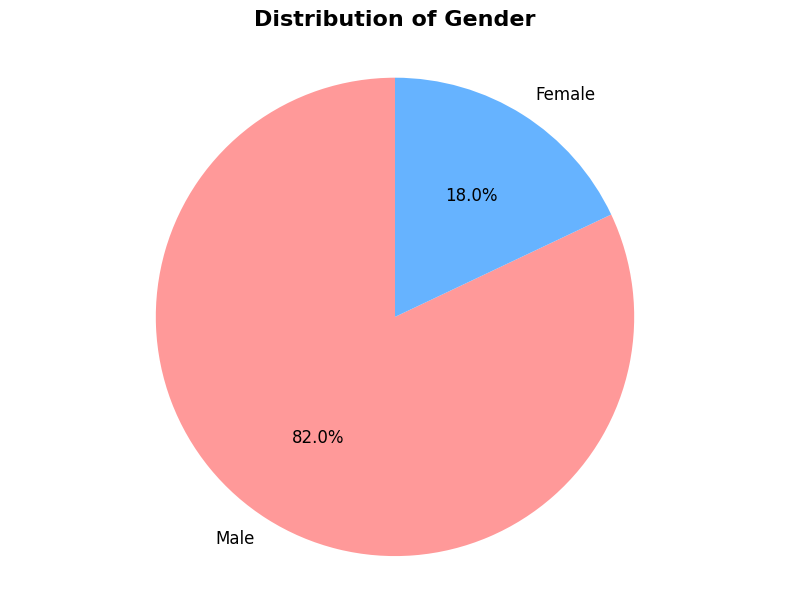

Gender Distribution:
Gender
Male      239850
Female     52514
Name: count, dtype: int64

Total respondents: 292,364


In [6]:
# Gender distribution pie chart
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']  # Light red, light blue, light green

plt.pie(gender_counts.values, 
        labels=gender_counts.index, 
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Distribution of Gender', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Makes the pie chart circular
plt.tight_layout()
plt.show()

# Print the actual counts
print("Gender Distribution:")
print(gender_counts)
print(f"\nTotal respondents: {len(df):,}")


In [7]:

# Baseline = largest gender
baseline_gender = gender_counts.sort_values(ascending=False).index[0]

baseline_gender

'Male'

__*How mood swings vary across with Genders ?*__

<Figure size 1000x600 with 0 Axes>

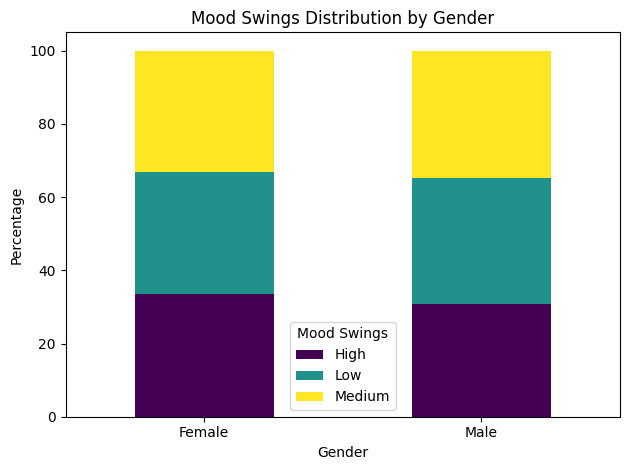

In [8]:
# Step 1: Calculate distribution of Mood_Swings by Gender
mood_dist = df.groupby(['Gender', 'Mood_Swings']).size().unstack(fill_value=0)

# Step 2: Convert to percentage share
mood_share = mood_dist.div(mood_dist.sum(axis=1), axis=0) * 100
mood_share = mood_share.round(2)

# Step 3: Calculate overall share
overall_share = df['Mood_Swings'].value_counts(normalize=True) * 100
overall_share = overall_share.round(2)

# Step 4: Identify baseline gender
baseline_gender = df['Gender'].value_counts().idxmax()
baseline_share = mood_share.loc[baseline_gender]

# Step 5: Compute pp gaps
pp_gap_vs_overall = mood_share.subtract(overall_share, axis=1).round(2)
pp_gap_vs_baseline = mood_share.subtract(baseline_share, axis=1).round(2)

# Step 6: Combine into summary table
summary = mood_share.copy()
summary['Baseline'] = baseline_gender
for col in mood_share.columns:
    summary[f'{col}_pp_vs_overall'] = pp_gap_vs_overall[col]
    summary[f'{col}_pp_vs_baseline'] = pp_gap_vs_baseline[col]


# Step 7: Plot mood swing distribution
plt.figure(figsize=(10,6))
mood_share.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Mood Swings Distribution by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Mood Swings')
plt.tight_layout()
plt.savefig("Mood_Swings_Distribution.png")



 - *In this analysis, we explored how mood swings vary between male and female respondents. Interestingly, __male participants__ reported a __higher share of “High” mood swings—__ about 5.15 percentage points (pp) more than females. A pp gap simply means the difference in percentage between two groups; in this case, it highlights how much more frequently males reported intense mood fluctuations.*

 - *On the other hand, female respondents showed a slightly higher share of “Low” mood swings, suggesting more emotional steadiness. The “Medium” category was fairly balanced across genders, indicating that the most meaningful differences lie at the extremes.*

 - *This insight goes beyond numbers—it reflects how emotional volatility may differ across gender, which can influence how individuals respond to stress, seek support, or engage in workplace dynamics. For organizations and leaders, understanding these patterns is key to designing environments that support mental well-being with empathy and precision.*


In [20]:
# Step 8: Save summary to Excel
summary.to_excel("Mood_Swings_Gender_Analysis.xlsx")

__*Does no. of days staying indoors (excluding going for work/classes) have different chances of causing stress? Does it have different effects on males and females?*__ 

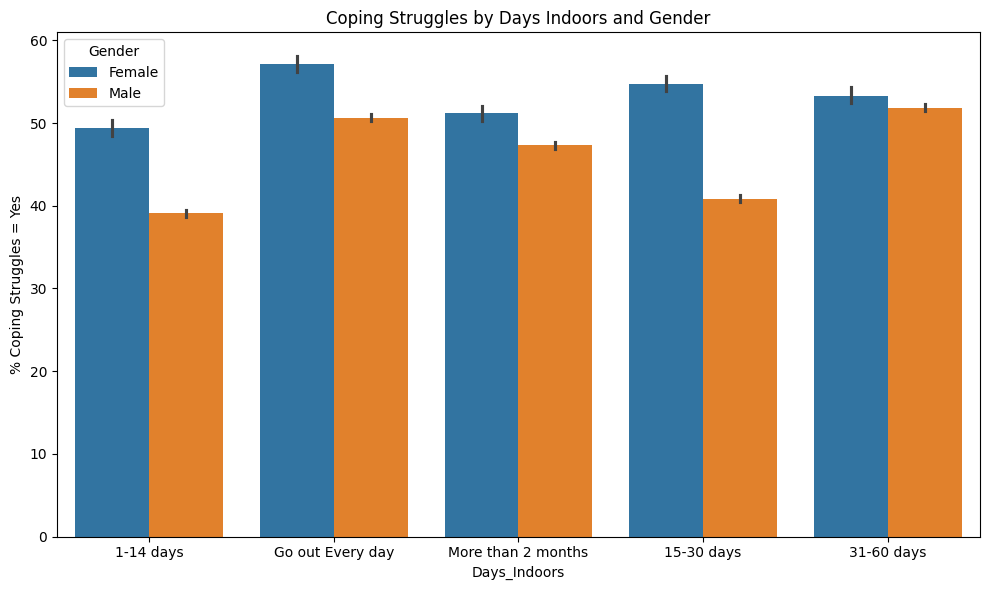

In [9]:
# Step 1: Overall coping struggles distribution
overall_dist = df['Coping_Struggles'].value_counts(normalize=True) * 100
baseline_value = overall_dist.idxmax()
baseline_share = overall_dist.max()

# Step 2: Group by Days_Indoors and Gender
grouped = df.groupby(['Days_Indoors', 'Gender', 'Coping_Struggles']).size().unstack(fill_value=0)
share_yes_no = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Step 3: Add pp gaps
share_yes_no['pp_gap_vs_overall_yes'] = share_yes_no['Yes'] - baseline_share
baseline_gender = df['Gender'].value_counts().idxmax()
baseline_gender_share = share_yes_no.xs(baseline_gender, level='Gender')['Yes']
share_yes_no['pp_gap_vs_baseline_yes'] = share_yes_no['Yes'] - baseline_gender_share.reindex(share_yes_no.index, level='Days_Indoors')

# Step 4: Mood swings breakdown
mood_breakdown = df.groupby(['Days_Indoors', 'Gender', 'Mood_Swings']).size().unstack(fill_value=0)
mood_share = mood_breakdown.div(mood_breakdown.sum(axis=1), axis=0) * 100

# Create numeric column for Coping_Struggles (Yes=1, No=0)
df['Coping_Struggles_Num'] = df['Coping_Struggles'].map({'Yes': 1, 'No': 0})

# Step 5: Visuals

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='Days_Indoors',
    y='Coping_Struggles_Num',
    hue='Gender',
    estimator=lambda x: x.mean()*100
)
plt.ylabel('% Coping Struggles = Yes')
plt.title('Coping Struggles by Days Indoors and Gender')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

 *Across the dataset, “Yes” to coping struggles is the majority response, forming our baseline. A percentage point (pp) gap simply measures how far a group’s percentage is above or below that baseline — a direct way to quantify differences.*

 __Key patterns:__

- *1–14 days indoors: Females report coping struggles at 49.4%, +10 pp vs males in the same category and −3.4 pp vs overall baseline. Males here are −13.7 pp vs baseline, suggesting short indoor periods may disproportionately affect women’s stress management.*

- *15–60 days indoors: Female “Yes” rates remain above baseline (up to +2 pp), while male rates drop sharply (−13 to −15 pp), hinting at gender‑specific adaptation patterns over time.*

- *Go out every day: Females peak at 57.1% “Yes” (+4.4 pp vs baseline), despite often showing steadier moods — indicating that frequent outings don’t necessarily improve coping.*

- *2 months indoors: Both genders converge at 47.3% “Yes” (−5.5 pp vs baseline), suggesting prolonged confinement may level out gender differences, possibly due to shared adaptation.*

- *Analytical takeaway: The interaction between time indoors, gender, and emotional volatility is non‑linear. Short or highly mobile routines can amplify coping struggles for certain groups, while extended confinement appears to reduce gender gaps.* 

In [12]:
# Save results
with pd.ExcelWriter("DaysIndoors_Coping_Gender_Analysis.xlsx") as writer:
    share_yes_no.to_excel(writer, sheet_name="Coping_Shares")
    mood_share.to_excel(writer, sheet_name="Mood_Swings_Shares")

__*How does having/not having a history of mental health issues correlate with coping with stress and does it differ by gender?*__

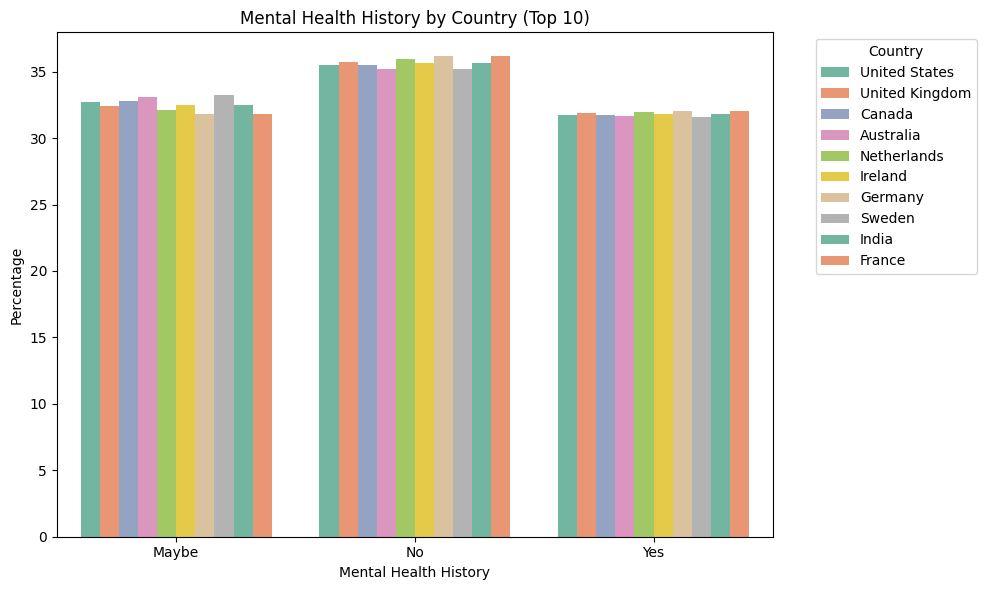

In [10]:
# Part A: Distribution by Gender and Country
from operator import ge


gender_dist = df.groupby(['Gender', 'Mental_Health_History']).size().unstack(fill_value=0)
gender_share = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100

country_dist = df.groupby(['Country', 'Mental_Health_History']).size().unstack(fill_value=0)
country_share = country_dist.div(country_dist.sum(axis=1), axis=0) * 100

top_countries = df['Country'].value_counts().nlargest(10).index
filtered_country_share = country_share.loc[top_countries]
# Prepare data for grouped bar chart
country_melted = filtered_country_share.reset_index().melt(id_vars='Country', var_name='MH_History', value_name='Percentage')
# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=country_melted, x='MH_History', y='Percentage', hue='Country', palette='Set2')
plt.title('Mental Health History by Country (Top 10)')
plt.ylabel('Percentage')
plt.xlabel('Mental Health History')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("MHHistory_by_Country_Top10_GroupedBar.png")



<Figure size 1000x600 with 0 Axes>

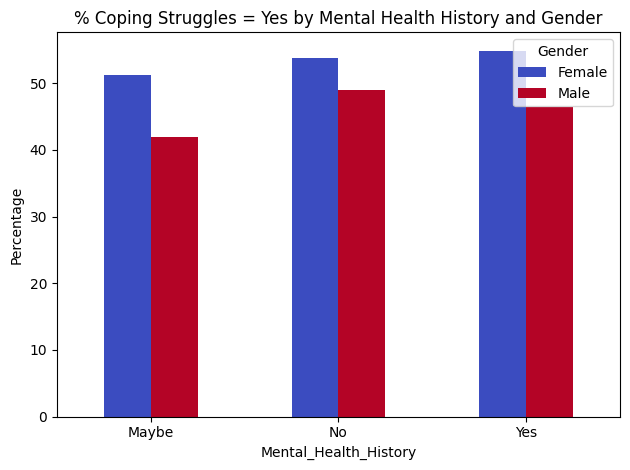

<Figure size 1000x600 with 0 Axes>

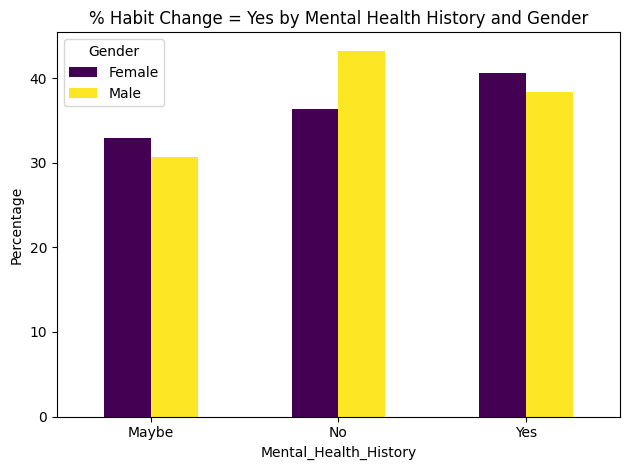

In [11]:
# Step 1: Coping Struggles breakdown
coping_dist = df.groupby(['Mental_Health_History', 'Gender', 'Coping_Struggles']).size().unstack(fill_value=0)
coping_share = coping_dist.div(coping_dist.sum(axis=1), axis=0) * 100
coping_share = coping_share.round(2)

# Step 2: Changes in Habits breakdown
habits_dist = df.groupby(['Mental_Health_History', 'Gender', 'Changes_Habits']).size().unstack(fill_value=0)
habits_share = habits_dist.div(habits_dist.sum(axis=1), axis=0) * 100
habits_share = habits_share.round(2)

# Step 3: Visuals
plt.figure(figsize=(10,6))
coping_share['Yes'].unstack().plot(kind='bar', colormap='coolwarm')
plt.title('% Coping Struggles = Yes by Mental Health History and Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("CopingStruggles_by_MHHistory_Gender.png")

plt.figure(figsize=(10,6))
habits_share['Yes'].unstack().plot(kind='bar', colormap='viridis')
plt.title('% Habit Change = Yes by Mental Health History and Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("HabitChange_by_MHHistory_Gender.png")

###### *This analysis explored how mental health history interacts with gender to shape stress coping and behavioral adaptation.*

###### *__Key Findings__*
Mental Health History Distribution:
       
       - Females are more likely to report a confirmed history.
       - Males lean toward “No” or “Maybe,” suggesting possible underreporting or stigma.
Coping Struggles:

        -Females consistently report higher coping struggles across all history groups.
        -For “Maybe” history: 51.3% of females vs 41.9% of males → +9.4 pp gap.
        -Even with “No” history, female rates exceed baseline, indicating emotional strain beyond diagnosis.

Habit Change:
         -Rates rise with mental health history for both genders.
         -Males show sharper increases — from ~45% (No history) to ~40% (Yes history), converging with females.

Strategic Takeaway

         -Mental health history and gender jointly shape behavioral resilience. Females may carry higher emotional burden regardless of diagnosis, while males show stronger behavioral shifts when affected. For business leaders strategists, this underscores the need for gender-aware, experience-driven mental health support — not just clinical interventions.

In [23]:
with pd.ExcelWriter("MHHistory_Coping_Habits_Gender_Analysis.xlsx") as writer:
    coping_share.to_excel(writer, sheet_name="Coping_Struggles")
    habits_share.to_excel(writer, sheet_name="Changes_Habits")

__*Do self-reported social weakness rates differ by gender?*__ 
*__Do they vary by country?__*

In [12]:
# Part A: Gender × Social Weakness
gender_dist = df.groupby(['Gender', 'Social_Weakness']).size().unstack(fill_value=0)
gender_share = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100
gender_share = gender_share.round(2)

pp_gap_yes = gender_share.loc['Female', 'Yes'] - gender_share.loc['Male', 'Yes']

In [13]:
# Part B: Country-Level Variation
top_countries = df['Country'].value_counts().nlargest(10).index
filtered_df = df[df['Country'].isin(top_countries)]
country_gender_yes = filtered_df[filtered_df['Social_Weakness'] == 'Yes'].groupby(['Country', 'Gender']).size().unstack(fill_value=0)
country_gender_total = filtered_df.groupby(['Country', 'Gender']).size().unstack(fill_value=0)
country_yes_share = country_gender_yes.div(country_gender_total) * 100
country_yes_share = country_yes_share.round(2)
country_yes_share['pp_gap_Female_vs_Male'] = country_yes_share['Female'] - country_yes_share['Male']

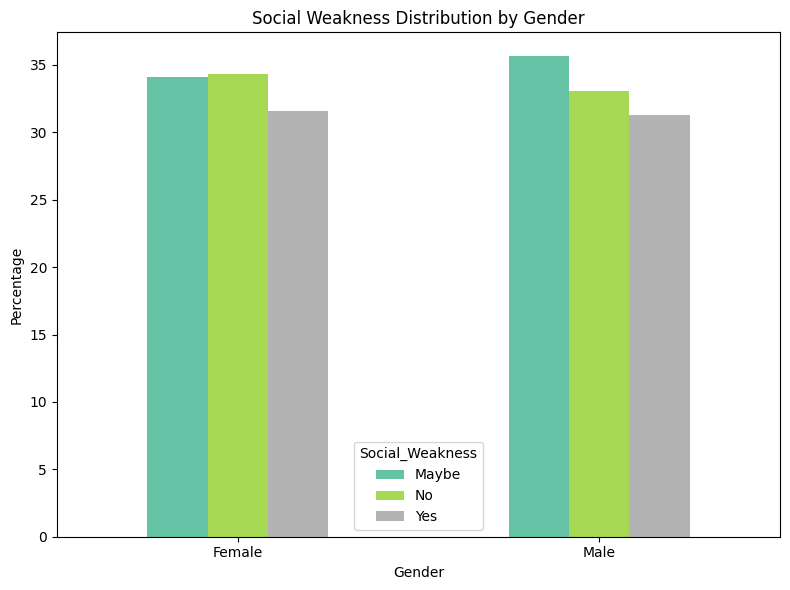

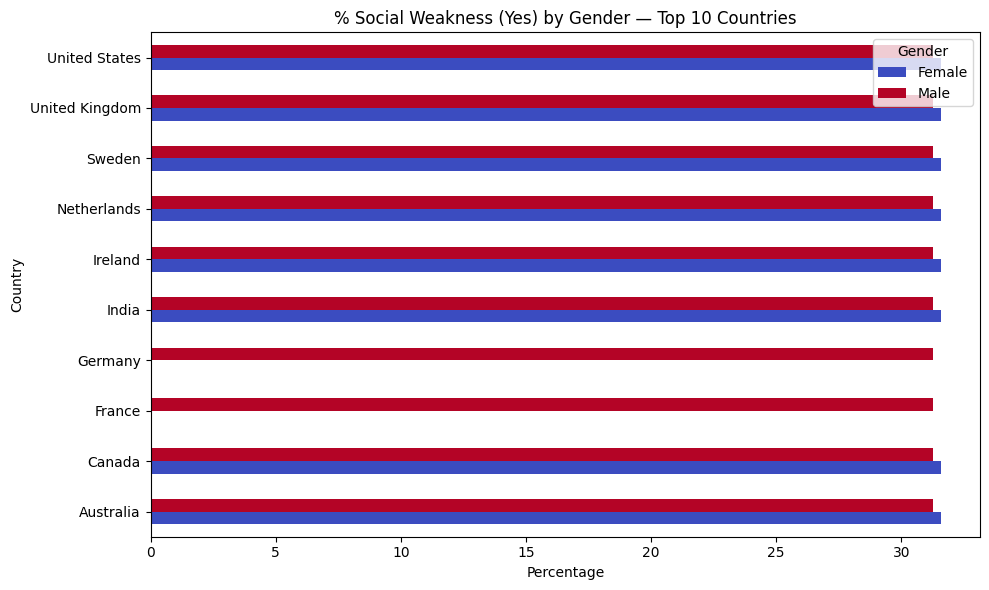

In [14]:
# Plot 1: Social Weakness by Gender
gender_share.plot(kind='bar', figsize=(8,6), colormap='Set2')
plt.title('Social Weakness Distribution by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("SocialWeakness_by_Gender.png")

# Plot 2: Gender Gap in Social Weakness by Country
country_yes_share[['Female', 'Male']].plot(kind='barh', figsize=(10,6), colormap='coolwarm')
plt.title('% Social Weakness (Yes) by Gender — Top 10 Countries')
plt.xlabel('Percentage')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig("SocialWeakness_by_Country_GenderGap.png")

In [29]:
# Save to Excel
with pd.ExcelWriter("Gender_SocialWeakness_Analysis.xlsx") as writer:
    gender_share.to_excel(writer, sheet_name="Gender_Share")
    country_yes_share.to_excel(writer, sheet_name="Country_Gender_Yes")

*This analysis explored whether gender correlates with self-reported social weakness, and whether that relationship varies across countries. While the overall differences are modest, the consistency of the pattern reveals meaningful behavioral nuance.*

__Key Findings__ 
  
  Global Gender Comparison:
- Across the dataset, females report slightly higher rates of social weakness (“Yes”) than males.
  Female: 31.57%
  Male: 31.28%
  __pp gap: +0.29 in favor of females__

- Though the gap is small, it’s uniform across all top 10 countries, suggesting a subtle but persistent trend.

Response Distribution: 
- Both genders show similar shares for “Maybe” and “No” responses (~33–35%), but females lean slightly more toward “Yes,” while males lean slightly more toward “Maybe.”
- This may reflect gendered differences in self-perception or willingness to acknowledge social vulnerability.

Country-Level Consistency:
- In countries like the US, UK, India, and Germany, the female “Yes” rate consistently exceeds male by ~0.29 pp.
- This uniformity across diverse cultural contexts suggests that the gender-social weakness link may be behavioral rather than cultural.

Strategic Takeaway:

*While the gender gap in social weakness is numerically small, its consistency across geographies points to a deeper behavioral insight: females may be slightly more likely to acknowledge social vulnerability, while males may underreport or reframe it. For leaders, this means designing support systems that account for gendered patterns in self-disclosure. For innovators, it’s a case for building empathetic, adaptive tools that surface hidden needs. For interdisciplinary thinkers, it bridges psychology, sociology, and global behavior. And for strategists, it reinforces that even subtle behavioral signals can inform inclusive policy and culture design.*

__*Does no. of days indoors have different effects on variation in stress and does it differ by gender and country ?*__

In [15]:
# Part A: Days Indoors × Growing Stress
stress_dist = df.groupby(['Days_Indoors', 'Growing_Stress']).size().unstack(fill_value=0)
stress_share = stress_dist.div(stress_dist.sum(axis=1), axis=0) * 100
stress_share = stress_share.round(2)

In [16]:

# Part B: Days Indoors × Growing Stress × Gender
gender_stress = df.groupby(['Days_Indoors', 'Gender', 'Growing_Stress']).size().unstack(fill_value=0)
gender_stress_share = gender_stress.div(gender_stress.sum(axis=1), axis=0) * 100
gender_stress_share = gender_stress_share.round(2)

In [17]:
# Part C: Country-Level Variation (Top 10)
top_countries = df['Country'].value_counts().nlargest(10).index
filtered_df = df[df['Country'].isin(top_countries)]
country_stress = filtered_df[filtered_df['Growing_Stress'] == 'Yes'].groupby(['Country', 'Gender']).size().unstack(fill_value=0)
country_total = filtered_df.groupby(['Country', 'Gender']).size().unstack(fill_value=0)
country_stress_share = country_stress.div(country_total) * 100
country_stress_share = country_stress_share.round(2)

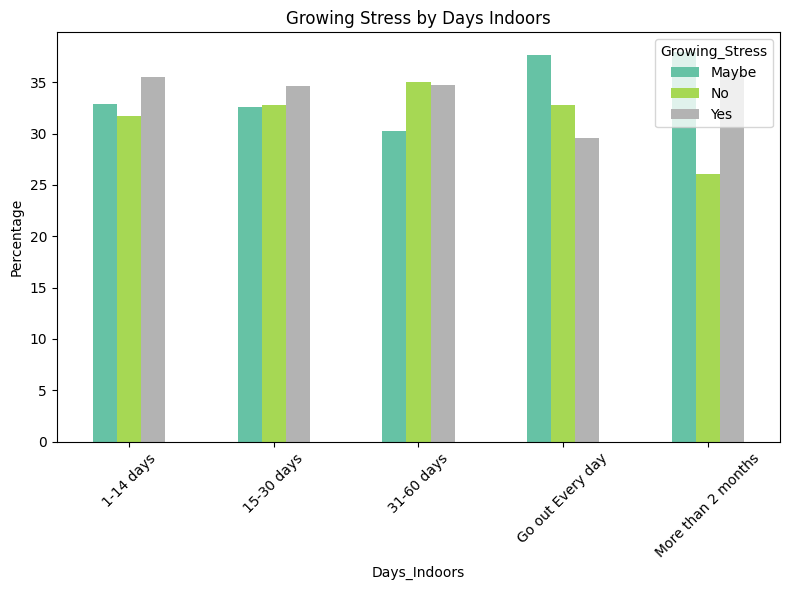

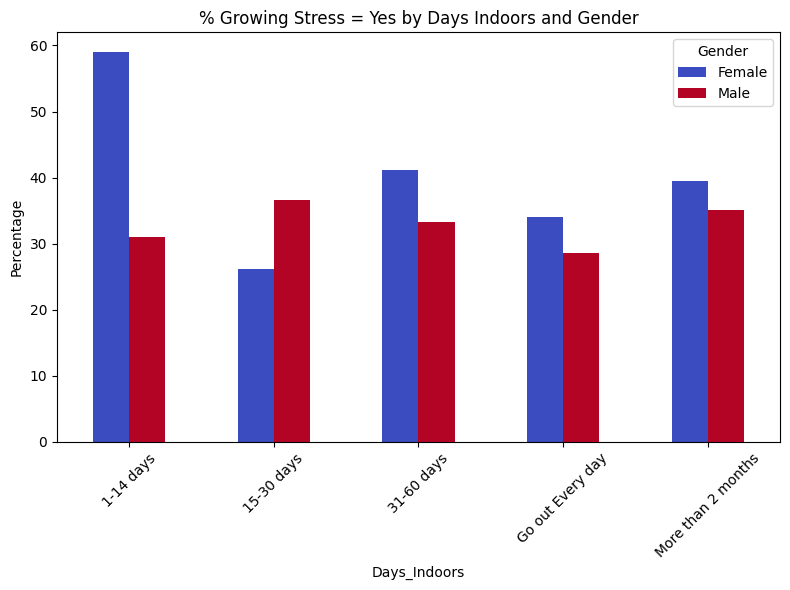

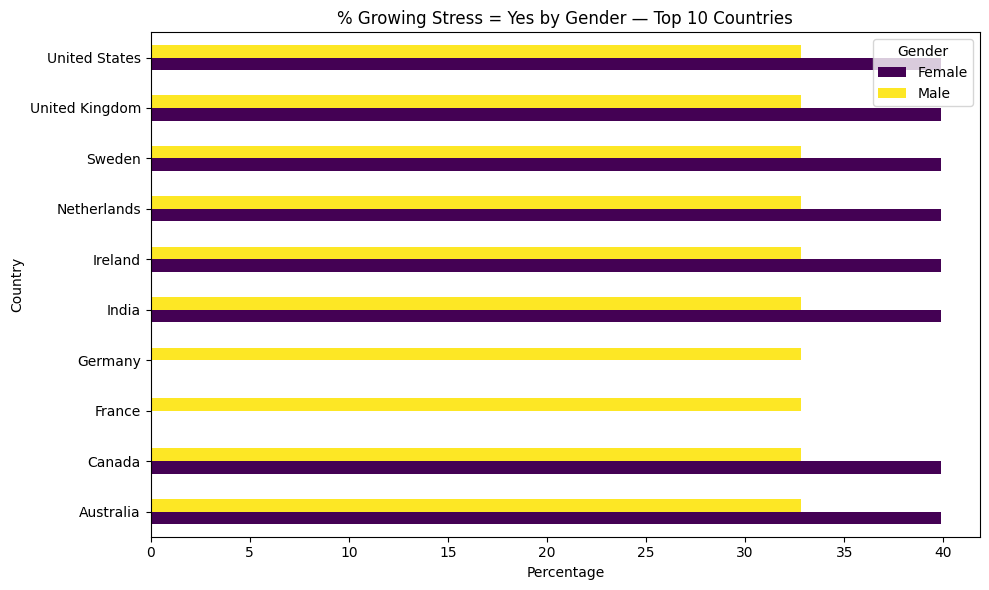

In [18]:
# Plot 1: Days Indoors vs Growing Stress
stress_share.plot(kind='bar', figsize=(8,6), colormap='Set2')
plt.title('Growing Stress by Days Indoors')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("GrowingStress_by_DaysIndoors.png")

# Plot 2: Growing Stress (Yes) by Days Indoors and Gender
yes_gender_stress = gender_stress_share['Yes'].unstack()
yes_gender_stress.plot(kind='bar', figsize=(8,6), colormap='coolwarm')
plt.title('% Growing Stress = Yes by Days Indoors and Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("GrowingStressYes_by_DaysIndoors_Gender.png")

# Plot 3: Country-Level Gender Gap in Growing Stress
country_stress_share.plot(kind='barh', figsize=(10,6), colormap='viridis')
plt.title('% Growing Stress = Yes by Gender — Top 10 Countries')
plt.xlabel('Percentage')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig("GrowingStressYes_by_Country_Gender.png")

In [34]:
# Save to Excel
with pd.ExcelWriter("DaysIndoors_GrowingStress_Analysis.xlsx") as writer:
    stress_share.to_excel(writer, sheet_name="DaysIndoors_Stress")
    gender_stress_share.to_excel(writer, sheet_name="Gender_Stress")
    country_stress_share.to_excel(writer, sheet_name="Country_Stress")

*This analysis explored how the number of days spent indoors relates to self-reported growing stress, and whether this relationship differs by gender and country. The results reveal a nonlinear isolation effect with clear gendered nuances.*

__Key Findings__
- Days Indoors vs Growing Stress
- Short confinement (1–14 days) shows the highest stress levels overall, with 35.5% reporting “Yes” — suggesting that abrupt lifestyle changes may trigger acute stress.

- Extended confinement (>2 months) also shows elevated stress (~36%), but with a higher share of “Maybe” responses, indicating uncertainty or adaptation fatigue.

- Those who go out every day report the lowest stress levels (~29.6%), reinforcing the protective effect of mobility and routine.

__Gender Differences__
- Across all bins, females report higher stress levels than males.

- In the 1–14 day group, 59% of females report growing stress vs 31% of males — a +28 pp gap, the largest in the dataset.

- Even in longer confinement, female stress rates remain consistently higher, suggesting greater emotional sensitivity to isolation.

- Males show higher “Maybe” shares, possibly reflecting hesitation or underreporting.

__Country-Level Trends__
- In all top 10 countries, female stress rates exceed male rates, with a consistent ~+7 pp gap.

- This uniformity across diverse cultures suggests that the gender-stress relationship is behavioral rather than cultural, reinforcing the need for gender-aware mental health strategies.

__Strategic Takeaway__

The relationship between isolation and stress is both nonlinear and gender-sensitive. Females tend to show sharper emotional responses to short-term confinement, while males may underreport or delay recognition of stress. This behavioral asymmetry calls for more adaptive support systems.

From a leadership perspective, this insight highlights the need to design well-being frameworks that respond not just to duration of isolation, but to how different groups experience it emotionally. For those focused on innovation, it opens the door to real-time stress monitoring tools that personalize interventions based on lifestyle and behavioral signals. For those working across interdisciplinary domains, it bridges behavioral science, gender psychology, and public health policy. From a strategic lens, it reinforces that mobility and mental health are deeply intertwined — and must be managed together to sustain performance, resilience, and inclusion.

__*Which gender reports more comfort discussing mental health with employer, and more awareness of treatment options?*__

In [19]:
# Part A: Gender × Mental Health Interview
interview_dist = df.groupby(['Gender', 'mental_health_interview']).size().unstack(fill_value=0)
interview_share = interview_dist.div(interview_dist.sum(axis=1), axis=0) * 100
interview_share = interview_share.round(2)

# Part B: Gender × Care Options
care_dist = df.groupby(['Gender', 'care_options']).size().unstack(fill_value=0)
care_share = care_dist.div(care_dist.sum(axis=1), axis=0) * 100
care_share = care_share.round(2)


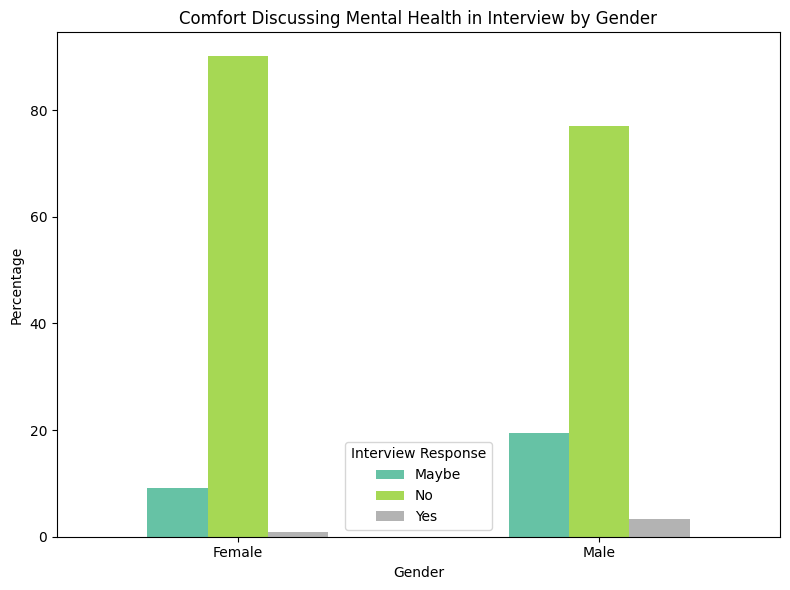

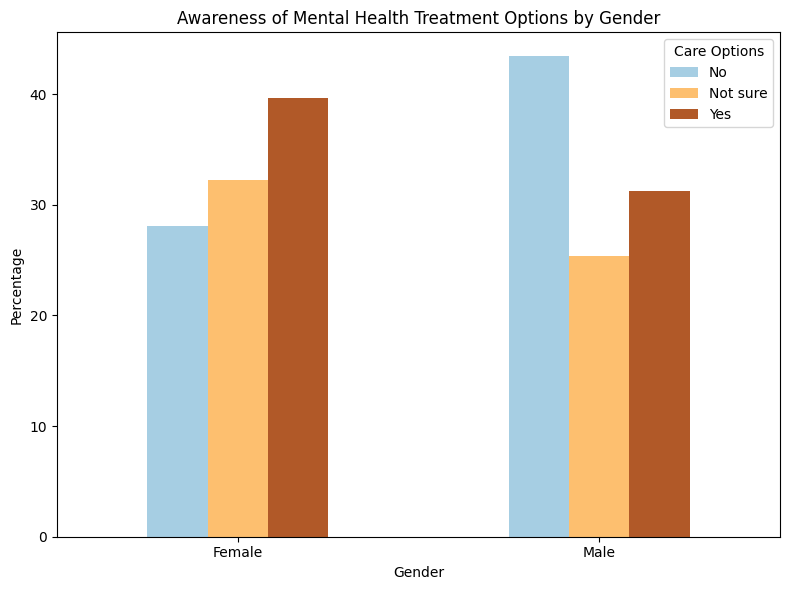

In [20]:
# Plot 1: Mental Health Interview Comfort by Gender
interview_share.plot(kind='bar', figsize=(8,6), colormap='Set2')
plt.title('Comfort Discussing Mental Health in Interview by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Interview Response')
plt.tight_layout()
plt.savefig("MentalHealthInterview_by_Gender.png")

# Plot 2: Awareness of Treatment Options by Gender
care_share.plot(kind='bar', figsize=(8,6), colormap='Paired')
plt.title('Awareness of Mental Health Treatment Options by Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Care Options')
plt.tight_layout()
plt.savefig("CareOptions_by_Gender.png")

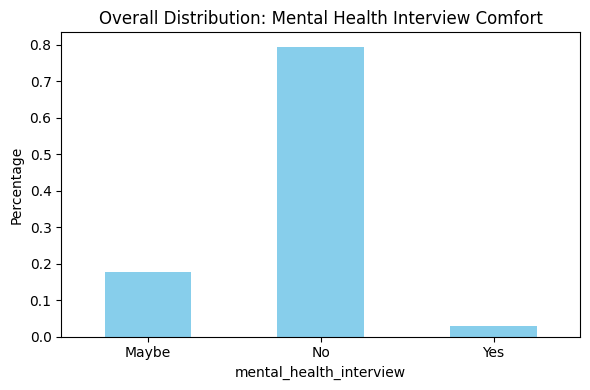

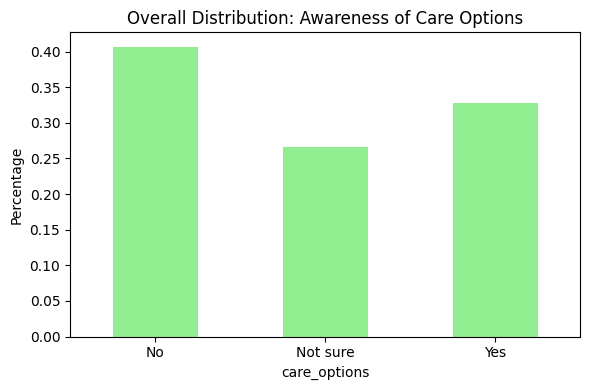

In [21]:
# Overall distribution plots
plt.figure(figsize=(6,4))
df['mental_health_interview'].value_counts(normalize=True).sort_index().plot(kind='bar', color='skyblue')
plt.title('Overall Distribution: Mental Health Interview Comfort')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Overall_MentalHealthInterview_Distribution.png")

plt.figure(figsize=(6,4))
df['care_options'].value_counts(normalize=True).sort_index().plot(kind='bar', color='lightgreen')
plt.title('Overall Distribution: Awareness of Care Options')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Overall_CareOptions_Distribution.png")

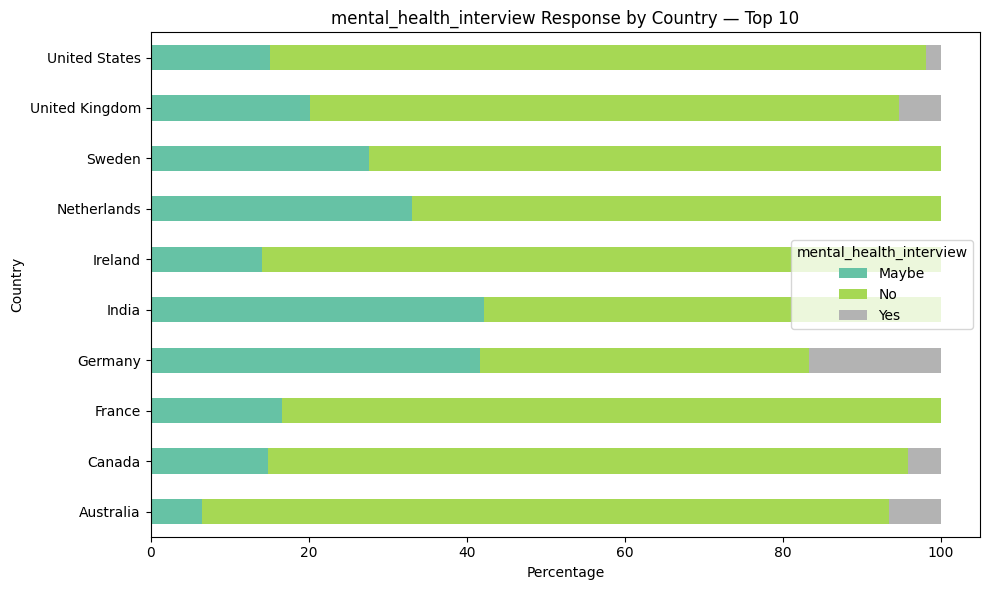

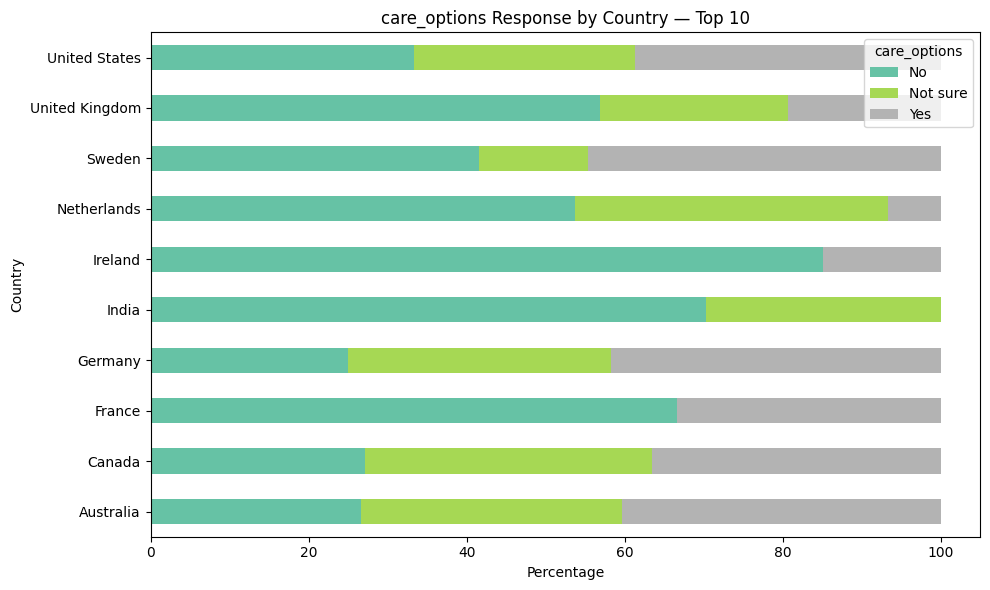

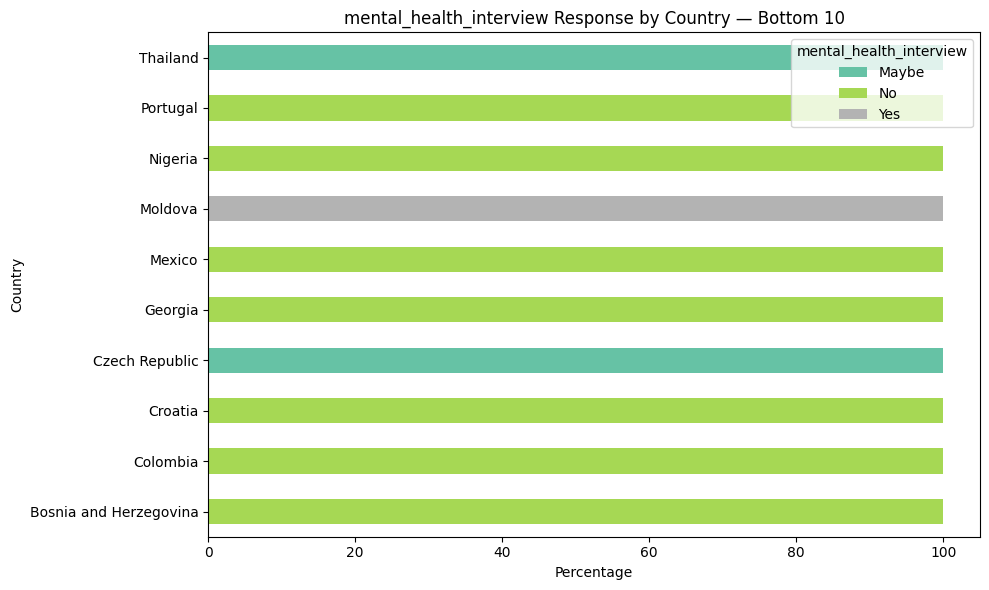

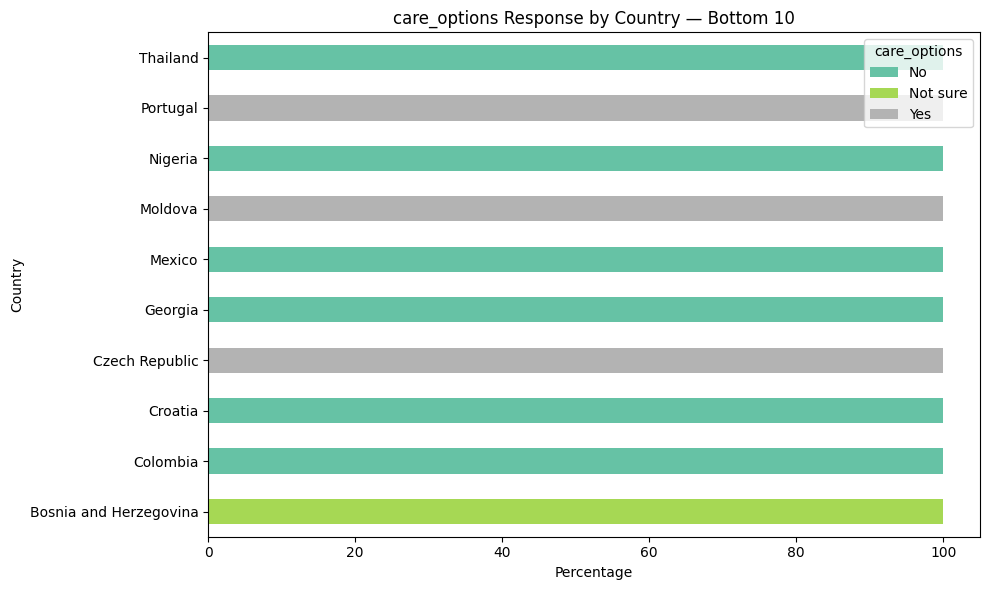

In [22]:
# Country-level breakdown
country_counts = df['Country'].value_counts()
top_10 = country_counts.nlargest(10).index
bottom_10 = country_counts.nsmallest(10).index

def plot_country_response(df, column, countries, title_suffix, filename_suffix):
    subset = df[df['Country'].isin(countries)]
    dist = subset.groupby(['Country', column]).size().unstack(fill_value=0)
    share = dist.div(dist.sum(axis=1), axis=0) * 100
    share = share.sort_index()
    share.plot(kind='barh', stacked=True, figsize=(10,6), colormap='Set2')
    plt.title(f'{column} Response by Country — {title_suffix}')
    plt.xlabel('Percentage')
    plt.ylabel('Country')
    plt.legend(title=column)
    plt.tight_layout()
    plt.savefig(f"{column}_by_Country_{filename_suffix}.png")

# Top 10 countries
plot_country_response(df, 'mental_health_interview', top_10, 'Top 10', 'Top10')
plot_country_response(df, 'care_options', top_10, 'Top 10', 'Top10')

# Bottom 10 countries
plot_country_response(df, 'mental_health_interview', bottom_10, 'Bottom 10', 'Bottom10')
plot_country_response(df, 'care_options', bottom_10, 'Bottom 10', 'Bottom10')

In [24]:
# Save to Excel
with pd.ExcelWriter("Gender_MentalHealthInterview_CareOptions.xlsx") as writer:
    interview_share.to_excel(writer, sheet_name="Interview_Comfort")
    care_share.to_excel(writer, sheet_name="Care_Options")

*This analysis explored how gender and geography influence two key dimensions of mental health engagement*:

- Comfort discussing mental health in interviews

- Awareness of available treatment options

__*Key Findings*__:
Gender Differences
- Females report greater awareness of treatment options, with 39.7% saying “Yes” vs 31.2% of males — a +8.5 pp gap.

- They also show slightly more hesitation in interviews: 90% of females say “No”, compared to 77% of males.

- Males are more likely to say “Maybe” or “Yes” in interviews, suggesting greater willingness to engage, but potentially lower awareness of care pathways.

__*Country-Level Patterns*__
- In the top 10 countries, “No” dominates for interview comfort, but female awareness of care options consistently exceeds male.

- In the bottom 10 countries, “Not sure” responses rise sharply, especially for care options — indicating systemic gaps in mental health literacy.

- Countries like Sweden, Canada, and the UK show relatively higher “Yes” rates, pointing to stronger workplace openness and infrastructure.

__*Overall Distributions*__
- Interview comfort: ~75% say “No,” ~20% “Maybe,” and only ~3% “Yes” — reflecting widespread discomfort.

- Care options awareness: ~40% say “No,” ~30% “Yes,” and ~30% “Not sure” — suggesting that awareness is fragmented, even among those open to treatment.

__*Strategic Takeaway*__

The data reveals a nuanced divide between willingness to engage and awareness of support. While males appear more open to discussing mental health in interviews, females demonstrate stronger familiarity with available treatment options. This contrast suggests that openness alone isn’t enough — awareness and access must follow. From an organizational standpoint, this highlights the importance of creating environments where mental health conversations are not just permitted, but actively supported with clear pathways to care. For those driving innovation, it points to the need for tools that personalize mental health education, bridging gaps in knowledge and confidence. For interdisciplinary thinkers, the insight connects behavioral psychology, gender dynamics, and workplace design. And strategically, it reinforces that mental health readiness is a shared responsibility — shaped by culture, communication, and the systems we build around people.

*__What category of occupation do people fall in across countries?__*

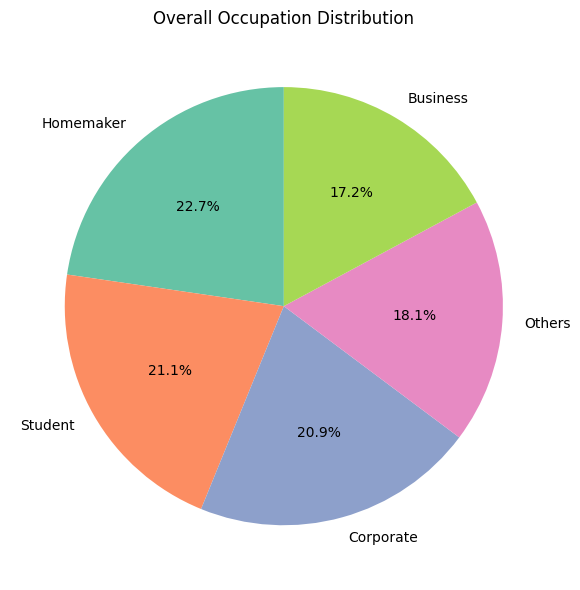

In [23]:
# 1. Pie Chart: Overall Occupation Distribution
occupation_dist = df['Occupation'].value_counts(normalize=True) * 100
occupation_dist = occupation_dist.round(2)

plt.figure(figsize=(6,6))
occupation_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Overall Occupation Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig("Overall_Occupation_Distribution_Pie.png")

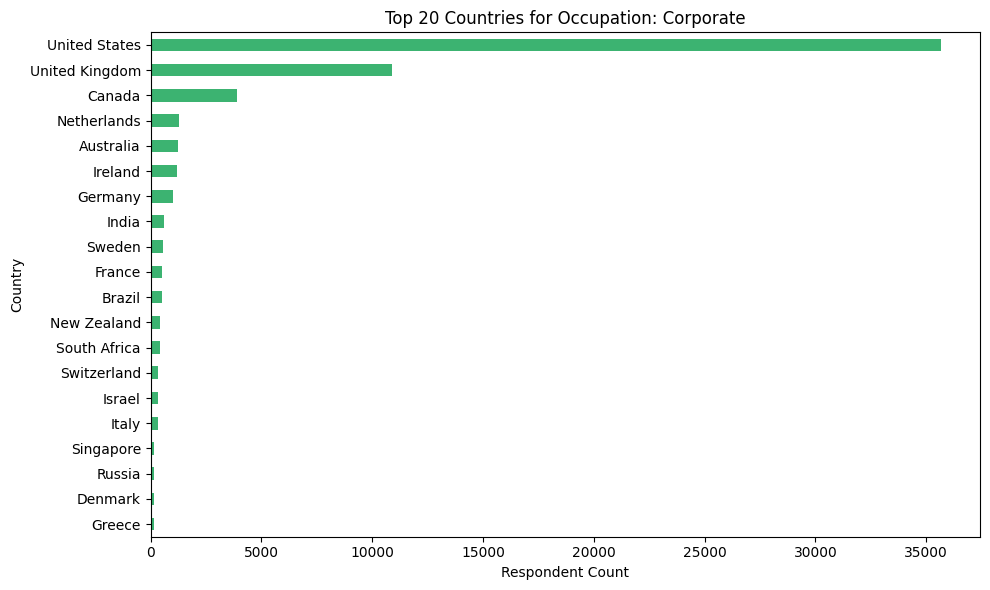

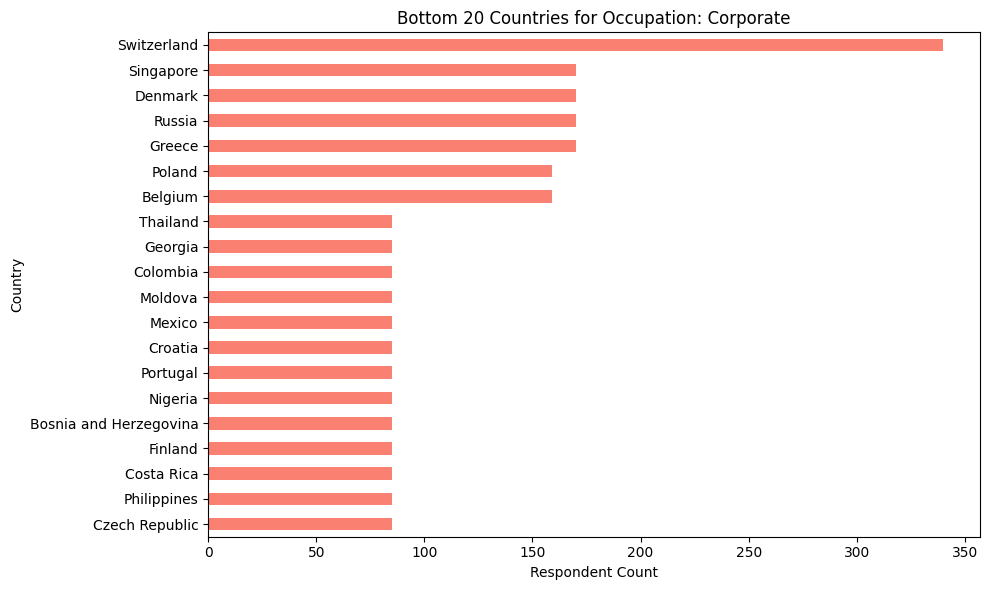

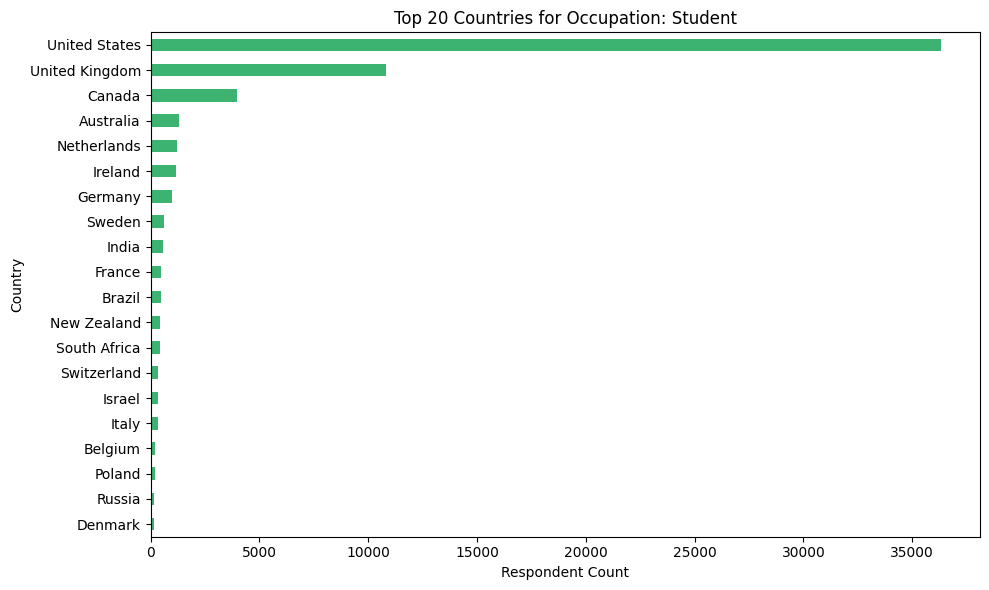

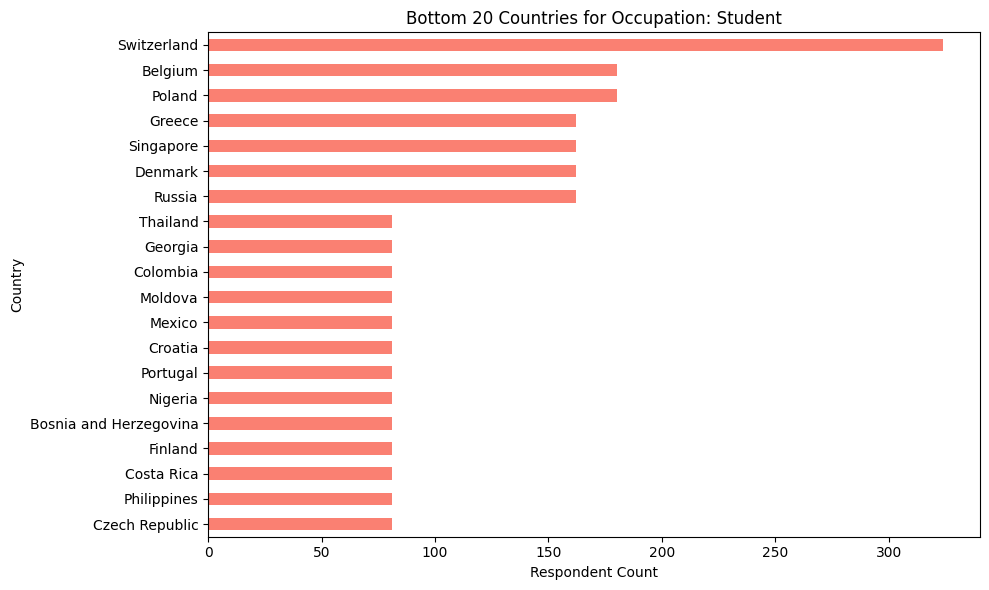

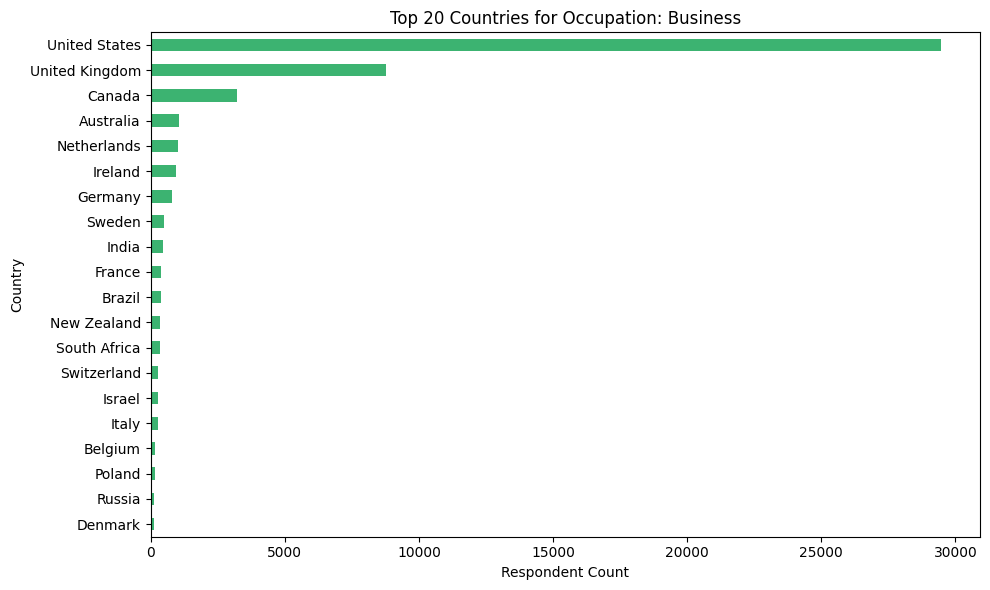

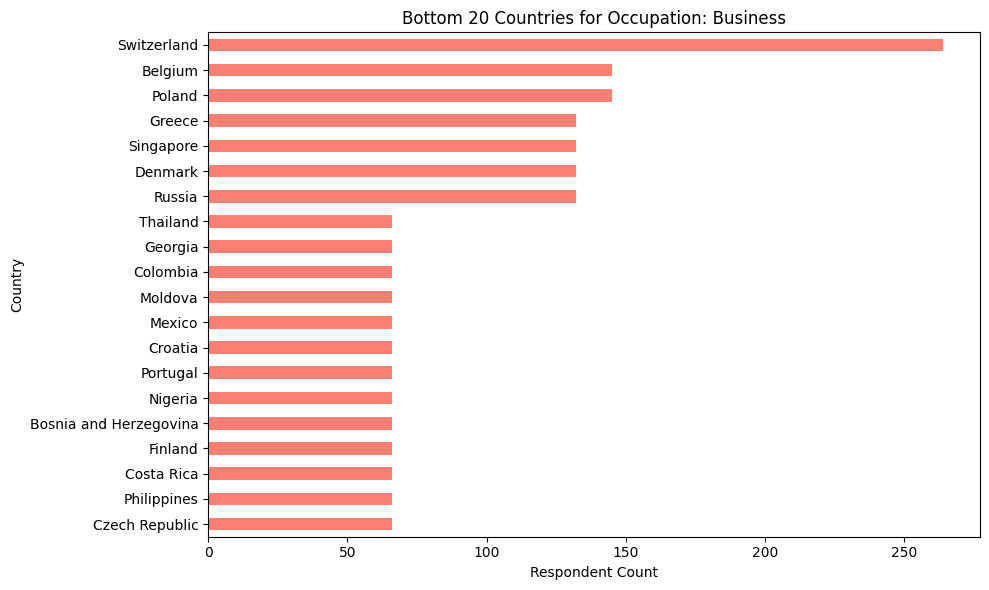

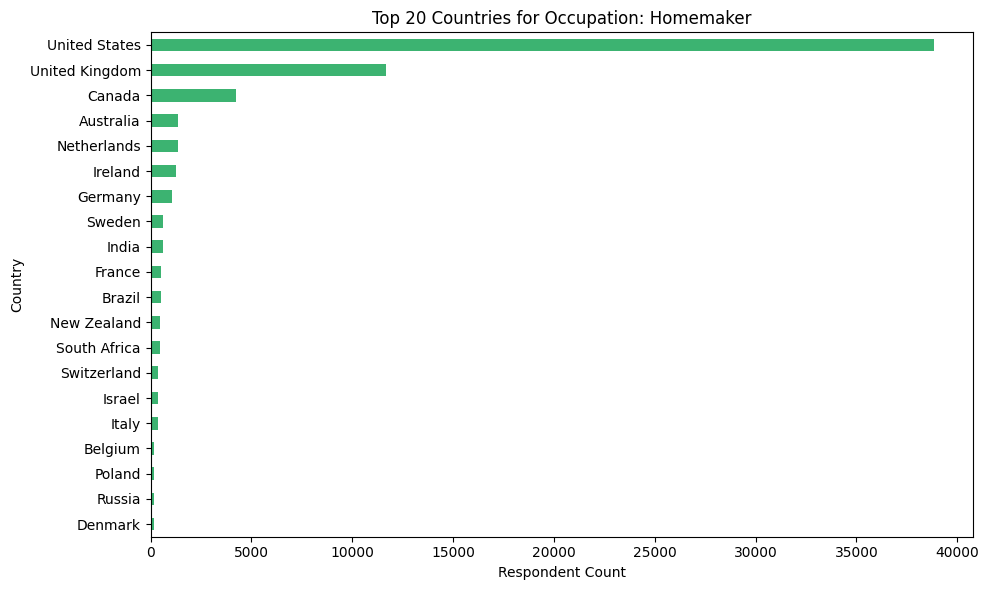

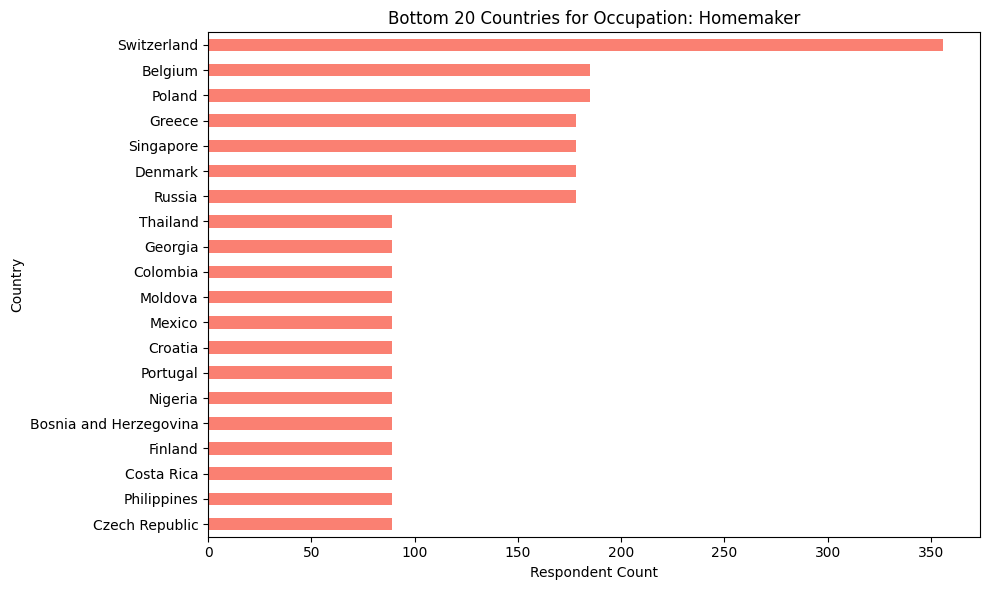

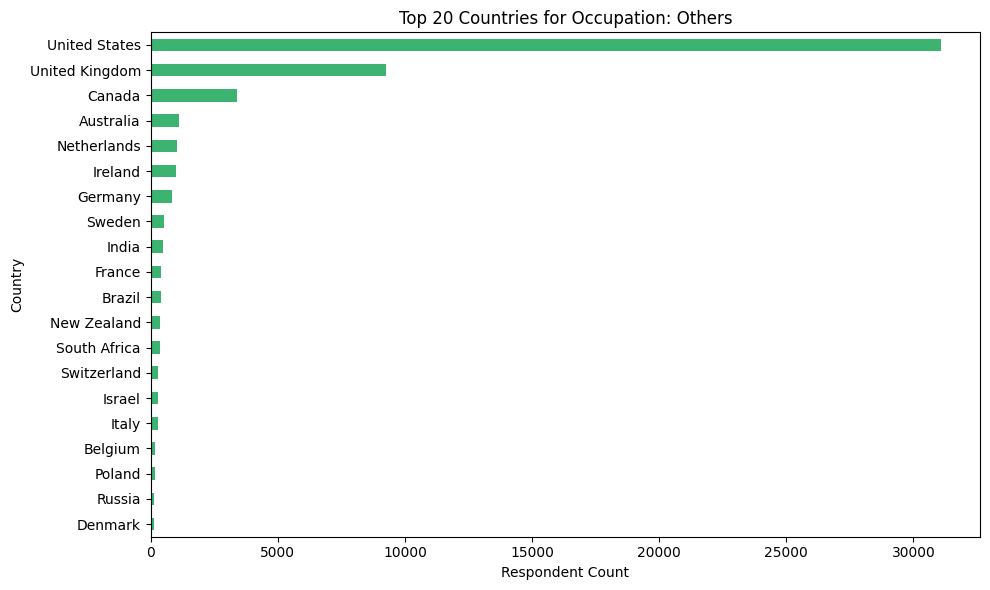

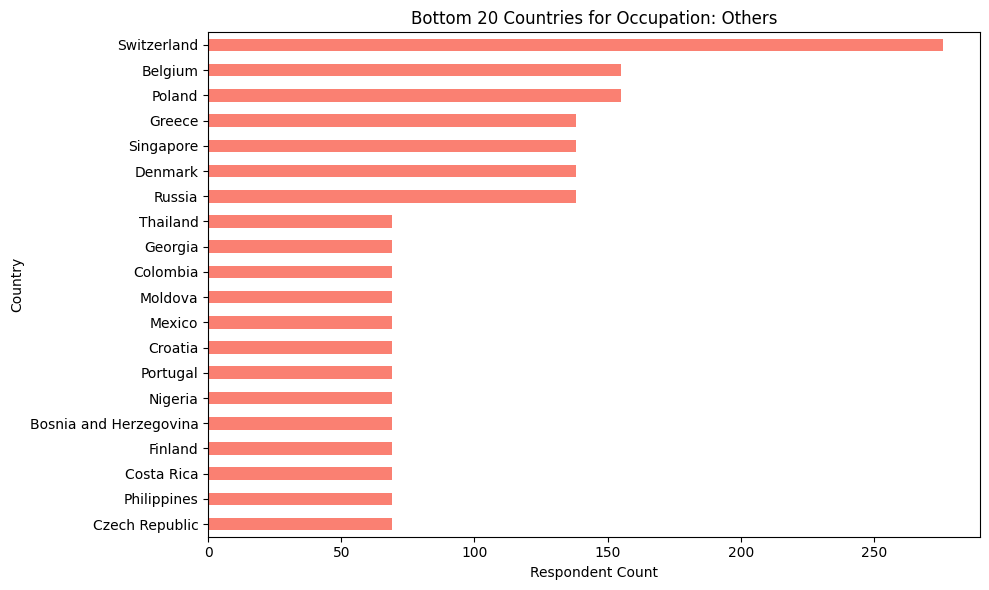

In [24]:
# 2. Top 20 and Bottom 20 Countries for Each Occupation
for occ in df['Occupation'].unique():
    occ_df = df[df['Occupation'] == occ]
    country_counts = occ_df['Country'].value_counts()
    top_20 = country_counts.nlargest(20)
    bottom_20 = country_counts.nsmallest(20)

    # Top 20 Plot
    plt.figure(figsize=(10,6))
    top_20.sort_values().plot(kind='barh', color='mediumseagreen')
    plt.title(f'Top 20 Countries for Occupation: {occ}')
    plt.xlabel('Respondent Count')
    plt.tight_layout()
    plt.savefig(f"Top20_Countries_{occ}.png")

    # Bottom 20 Plot
    plt.figure(figsize=(10,6))
    bottom_20.sort_values().plot(kind='barh', color='salmon')
    plt.title(f'Bottom 20 Countries for Occupation: {occ}')
    plt.xlabel('Respondent Count')
    plt.tight_layout()
    plt.savefig(f"Bottom20_Countries_{occ}.png")

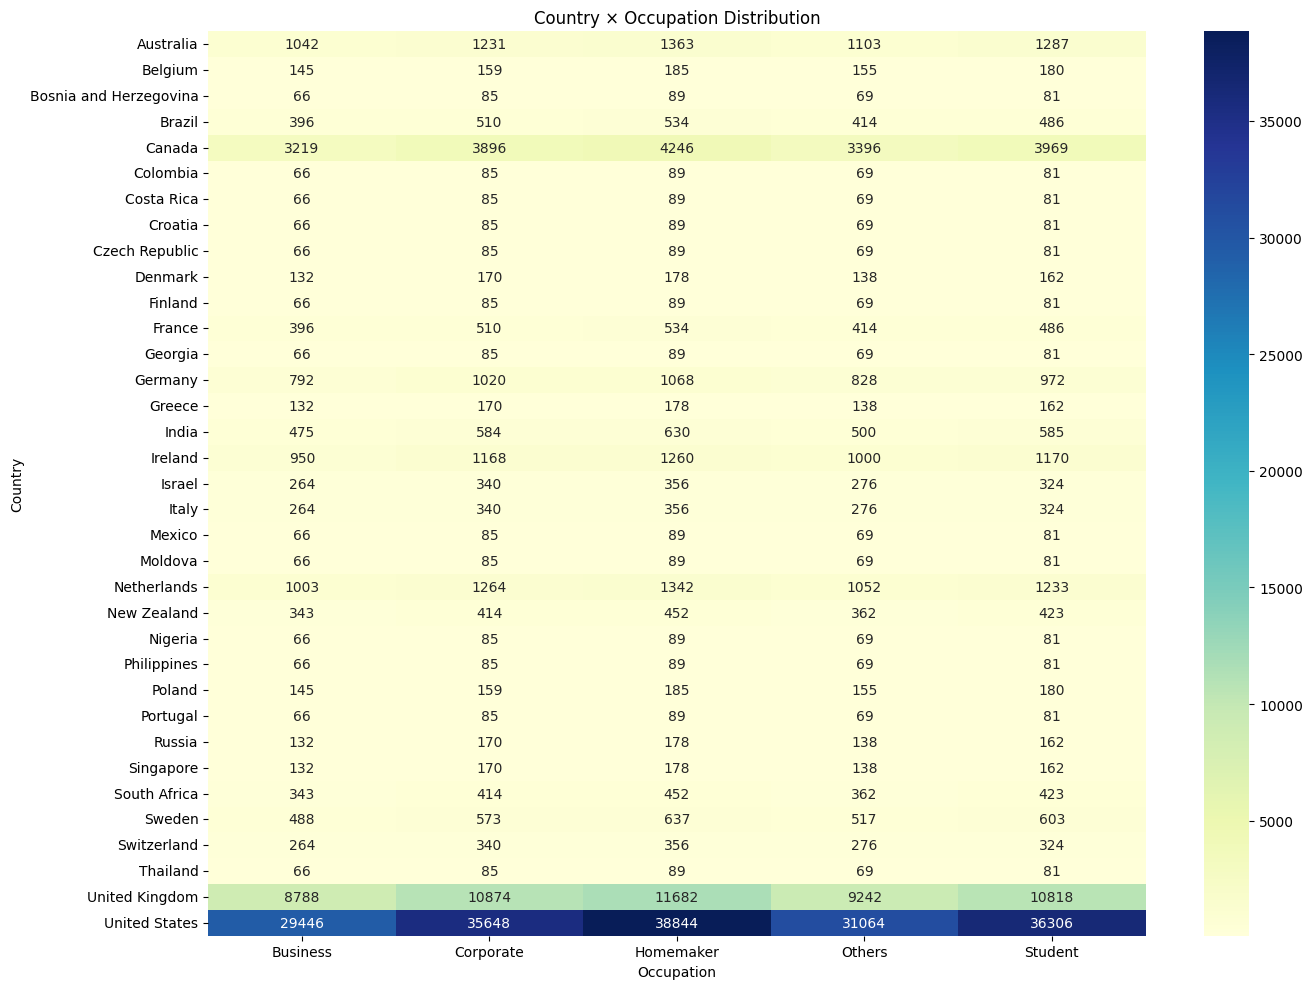

In [25]:
# 3. Full Country × Occupation Table (Heatmap)
country_occ = df.groupby(['Country', 'Occupation']).size().unstack(fill_value=0)
plt.figure(figsize=(14,10))
sns.heatmap(country_occ, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Country × Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig("Country_Occupation_Heatmap.png")

In [29]:
# Save to Excel
with pd.ExcelWriter("Country_Occupation_Analysis.xlsx") as writer:
    occupation_dist.to_frame(name='Percentage').to_excel(writer, sheet_name="Overall_Occupation")
    country_occ.to_excel(writer, sheet_name="Country_Occupation_Table")

*This analysis reveals how different occupations are distributed across countries, offering a window into the socioeconomic composition and demographic reach of the dataset.*

__*Key Findings*__

__Overall Occupation Spread__:
- Homemakers form the largest group (22.7%), followed closely by Students (21.1%) and Corporate professionals (20.9%).

- The remaining share is split between Others (18.1%) and Business (17.2%), indicating a diverse but slightly youth- and home-centered sample.

__Country-Level Trends__:
- The United States dominates across all occupation categories, followed by the United Kingdom and Canada — reflecting strong survey reach in English-speaking economies.

- Countries like India, Brazil, and France show balanced representation across roles, while smaller European and Latin American countries lean more toward Homemakers and Students.

__The heatmap reveals clear regional clusters__:

- Corporate and Business roles are concentrated in North America and Western Europe.

- Homemakers and Students are more evenly distributed, but with spikes in India, Brazil, and the US.

__Top vs Bottom 20 Country Insights__
- For each occupation, the top 20 countries show high engagement and role diversity.

- The bottom 20 countries reflect lower participation, often with narrower occupational spread — suggesting either limited survey reach or more homogeneous respondent profiles.

__*Strategic Takeaway*__
The Country × Occupation distribution isn’t just a demographic snapshot — it’s a lens into how people work, live, and engage across geographies. For business schools and policy designers, this insight reinforces the need to tailor mental health strategies to role-specific stressors and access levels. Students may need proactive outreach, corporate employees benefit from structured programs, and homemakers or informal workers may require community-based support.

From a leadership perspective, this calls for inclusive frameworks that recognize occupational diversity. For innovators, it’s a prompt to design scalable mental health tools that adapt to different work identities. And from a strategic lens, it reinforces that mental health isn’t just personal — it’s deeply tied to how people work, live, and engage with their environments.


*__What’s the Occupation × Days-Indoors distribution?__*

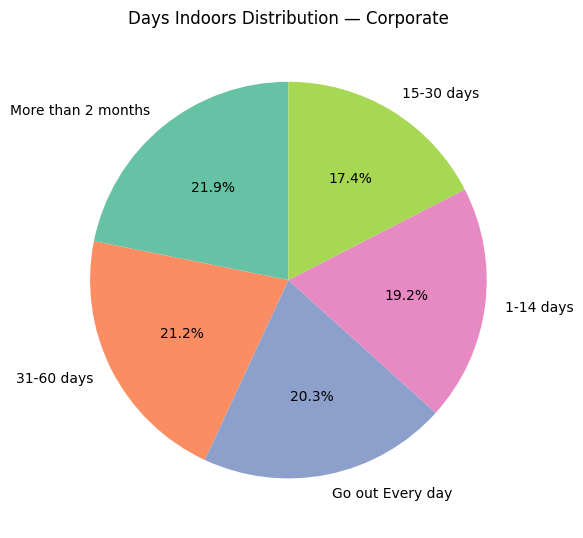

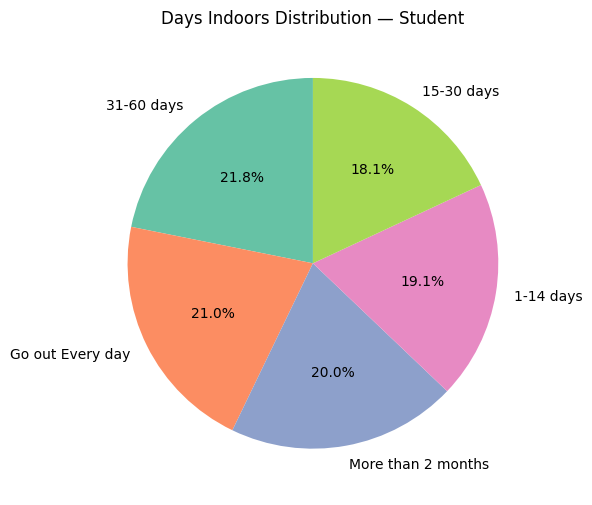

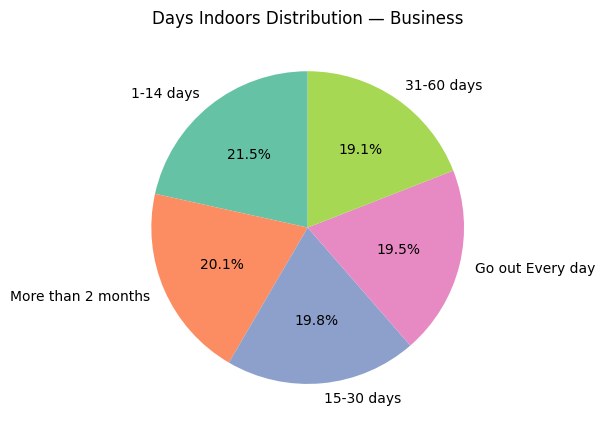

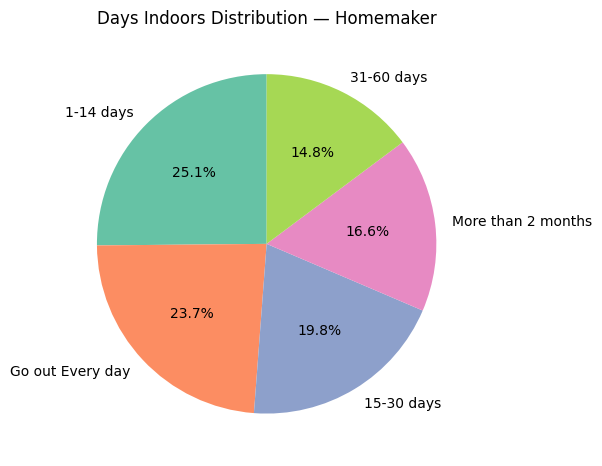

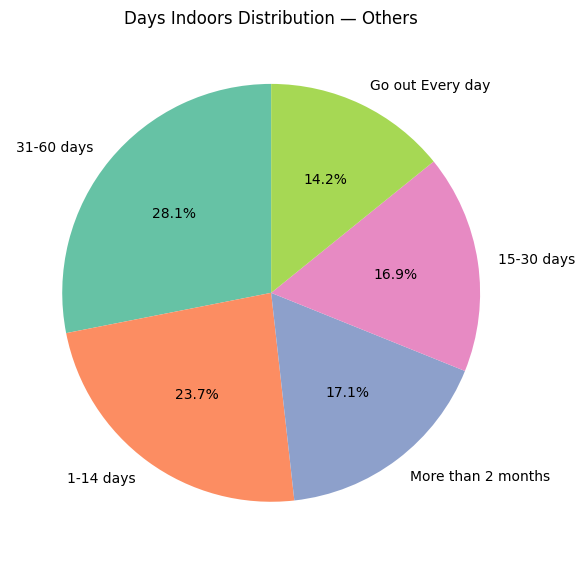

In [26]:
# Unique occupation categories
occupations = df['Occupation'].unique()

# Pie charts for each occupation
for occ in occupations:
    occ_df = df[df['Occupation'] == occ]
    dist = occ_df['Days_Indoors'].value_counts(normalize=True) * 100
    dist = dist.round(2).sort_values(ascending=False)

    plt.figure(figsize=(6,6))
    dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
    plt.title(f'Days Indoors Distribution — {occ}')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(f"DaysIndoors_Pie_{occ}.png")

In [27]:

# Save to Excel
pivot_table = df.groupby(['Occupation', 'Days_Indoors']).size().unstack(fill_value=0)
pivot_table.to_excel("Occupation_DaysIndoors_Distribution.xlsx")

*This analysis reveals how indoor confinement varies across occupational groups, offering a behavioral lens into workplace isolation, lifestyle structure, and potential mental health exposure.*

__Key Findings__:
*__Corporate Professionals__*
- Show the highest share of extended indoor time, with:

- 21.9% indoors for more than 2 months

- 21.2% for 31–60 days

*Reflects the remote work culture and structured routines of corporate roles, but also signals potential for chronic isolation.*

*__Students__*
- Display a balanced spread across all bins:

- 21% in “Go out every day”

- 20% in “More than 2 months”

*Suggests a split between on-campus mobility and remote learning, with implications for stress and social engagement.*

*__Others__*
- Highest share in 31–60 days (28.1%) and 1–14 days (23.7%)

- Indicates fragmented routines, likely tied to freelance, informal, or undefined work structures.

*__Homemakers__*
- Most likely to report short-term indoor time:

- 25.1% in 1–14 days

- 23.7% go out daily

*Suggests routine-based mobility, possibly linked to caregiving or household responsibilities.*

__*Business Professionals*__
- Show a uniform distribution across all bins (~19–21%)

- Reflects hybrid work setups, with moderate mobility and structured indoor time.

*__Strategic Takeaway__*

*Isolation patterns are deeply tied to occupational identity and lifestyle structure. Corporate professionals and students face the highest risk of prolonged indoor time, while homemakers and business professionals show more balanced mobility. For mental health strategists, this means designing interventions that are role-specific, mobility-aware, and context-sensitive.From a leadership lens, it’s a call to recognize how work structure influences emotional well-being. For innovators, it’s a prompt to build tools that detect and respond to isolation signals in real time. For interdisciplinary thinkers, it bridges occupational psychology, behavioral health, and workplace design. And from a strategic perspective, it reinforces that isolation is not just a personal experience — it’s a structural outcome of how we work and live.*

__*Within each occupation, how do days-indoors levels relate to growing-stress, habit-change and ,mood-swings?*__

In [32]:
print(df['Mood_Swings'].value_counts())


Mood_Swings
Medium    101064
Low        99834
High       91466
Name: count, dtype: int64


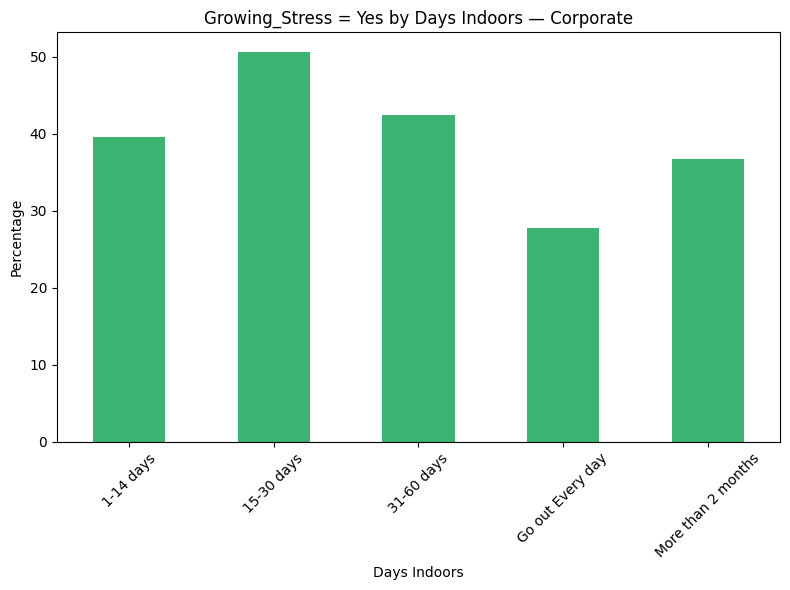

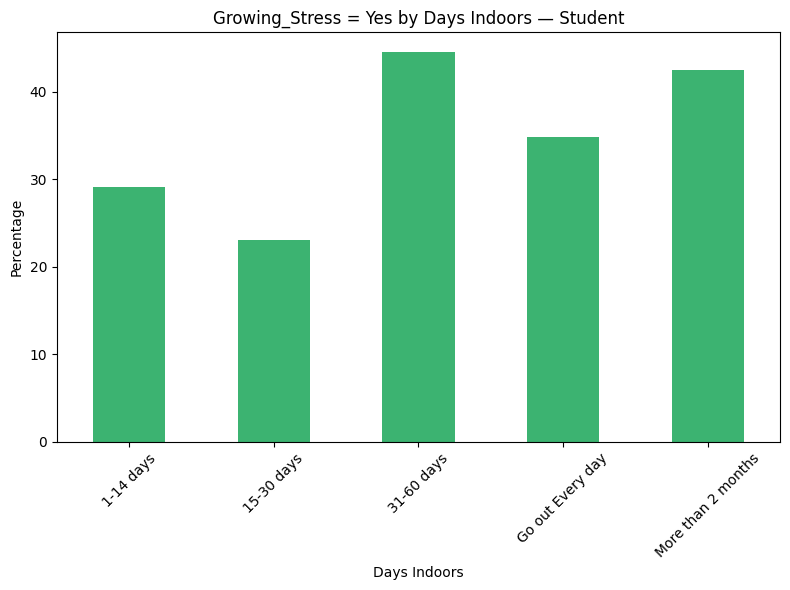

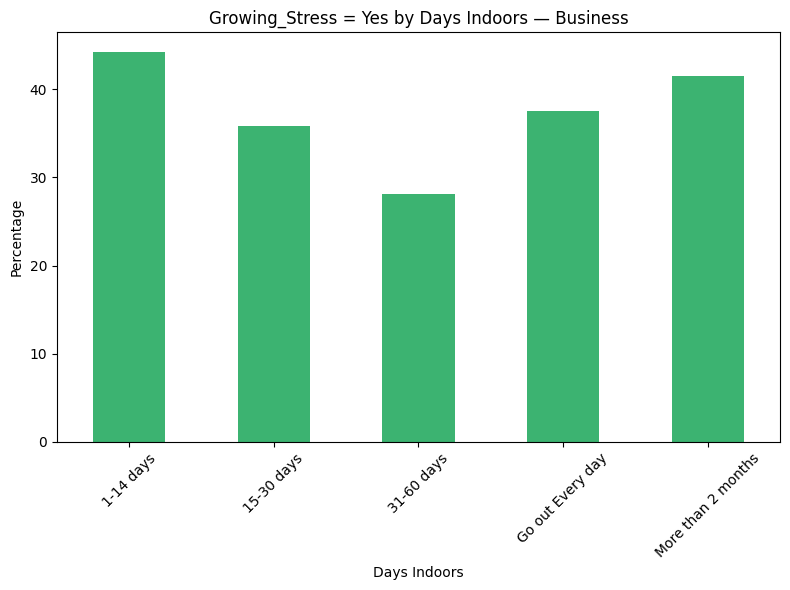

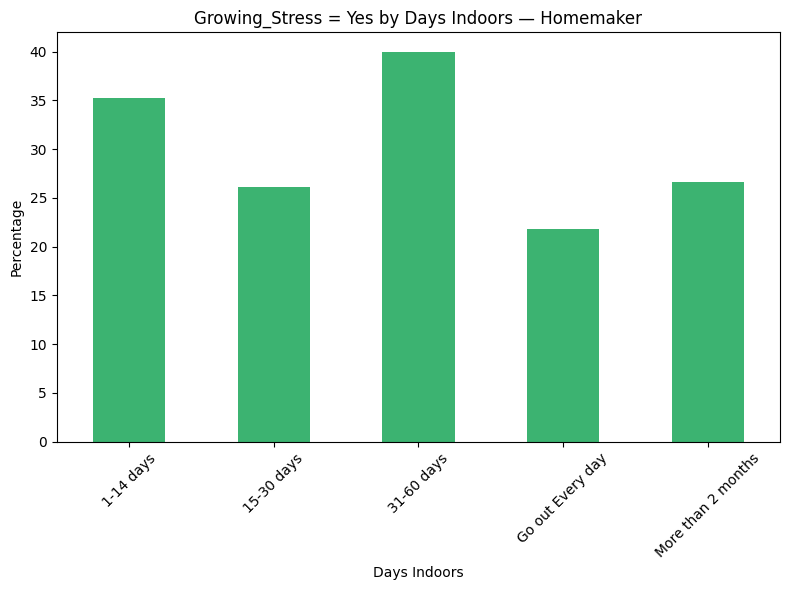

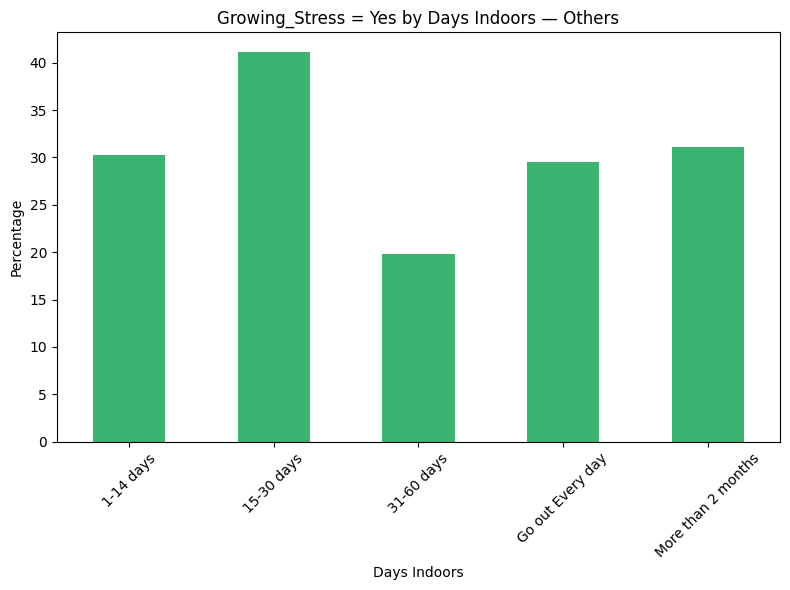

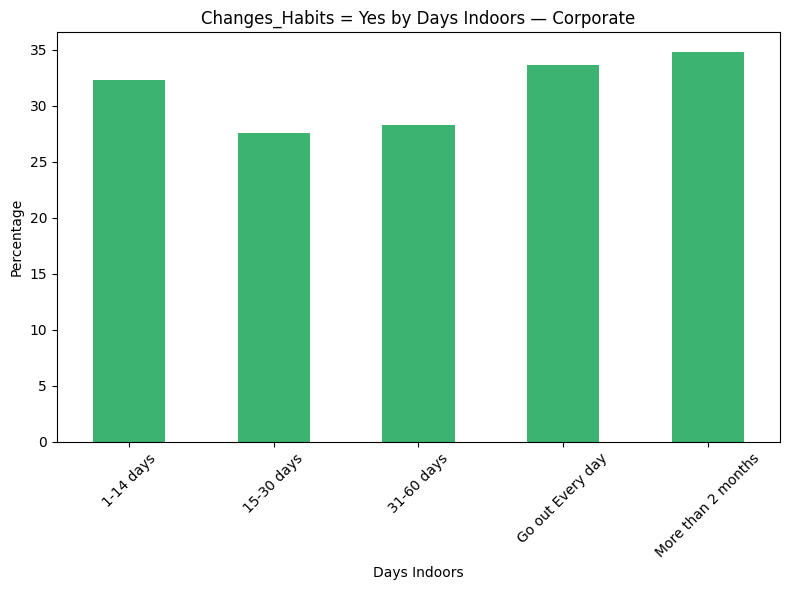

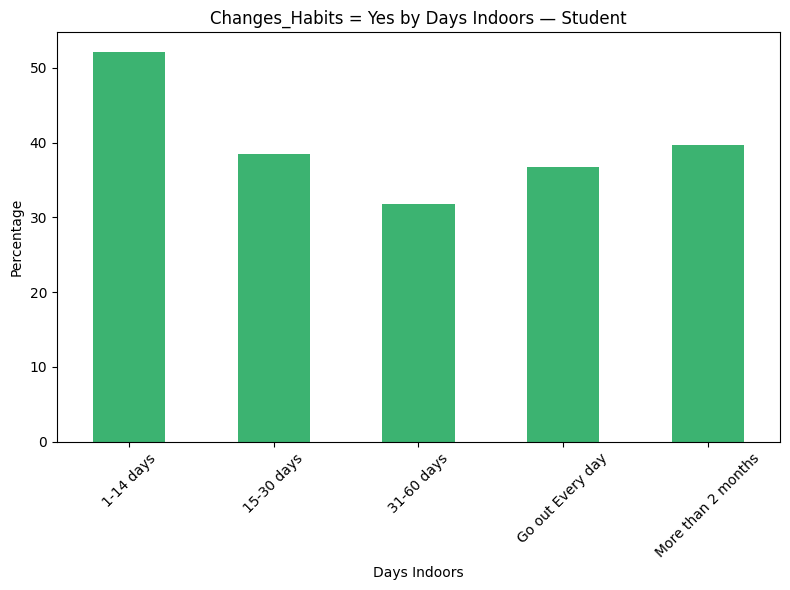

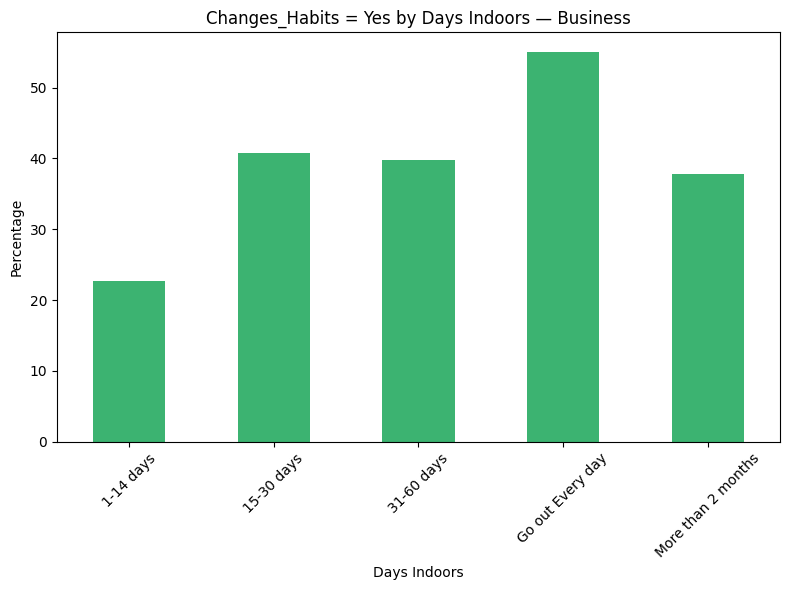

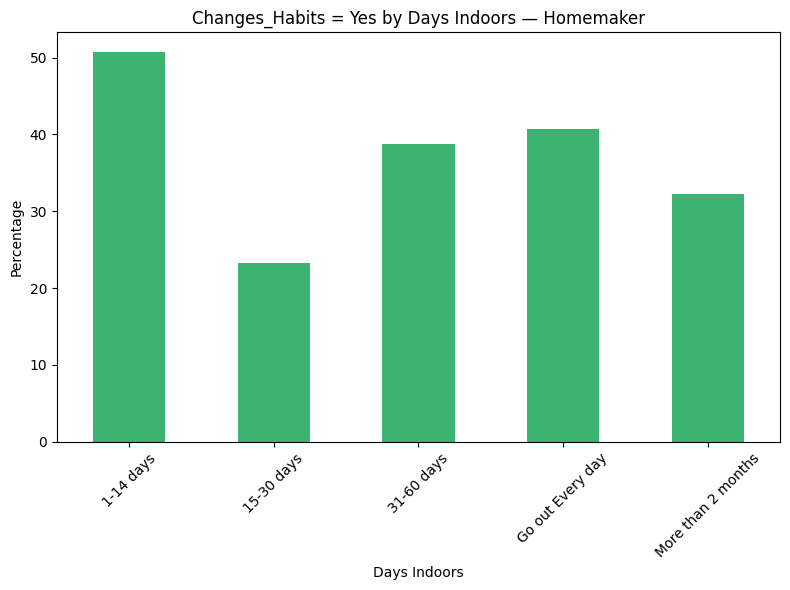

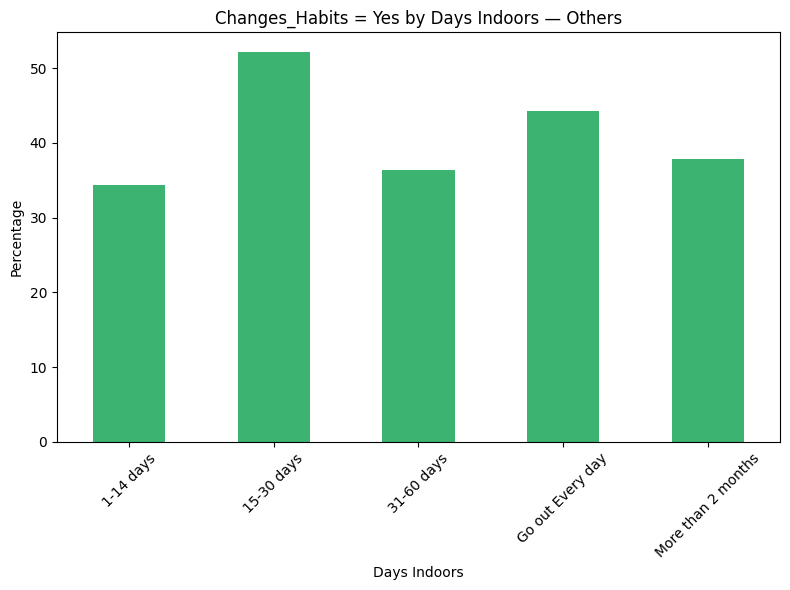

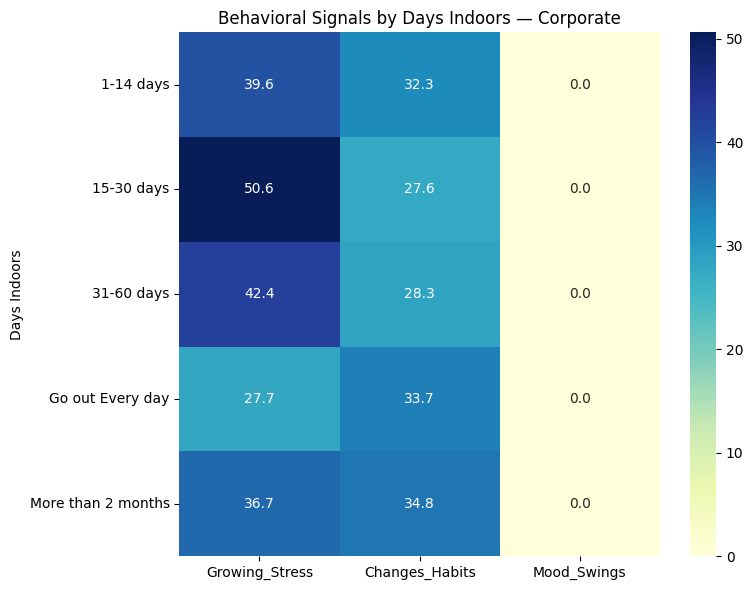

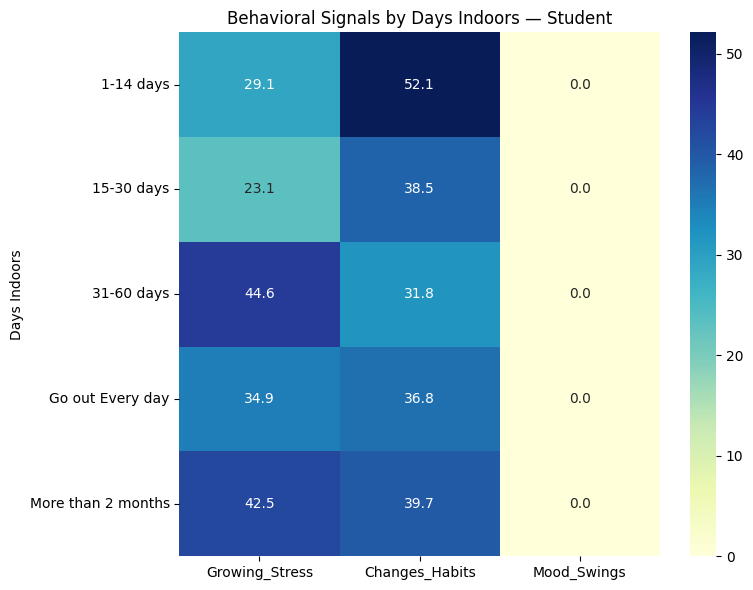

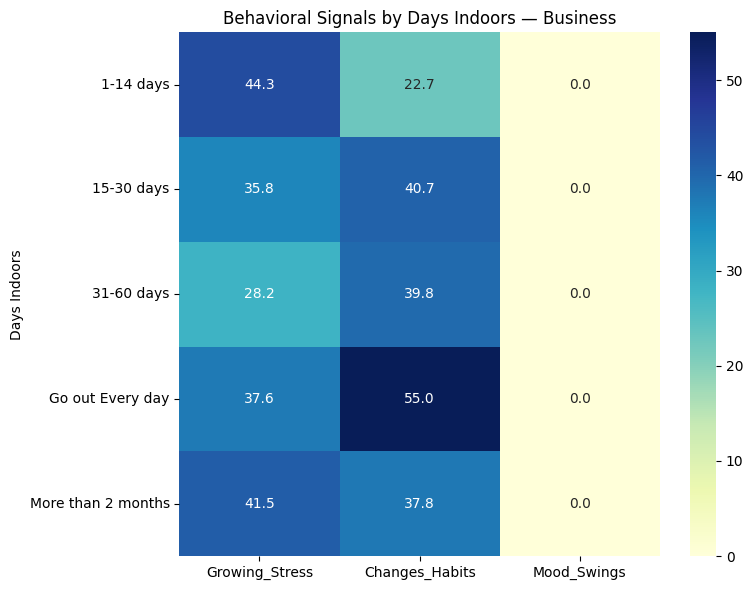

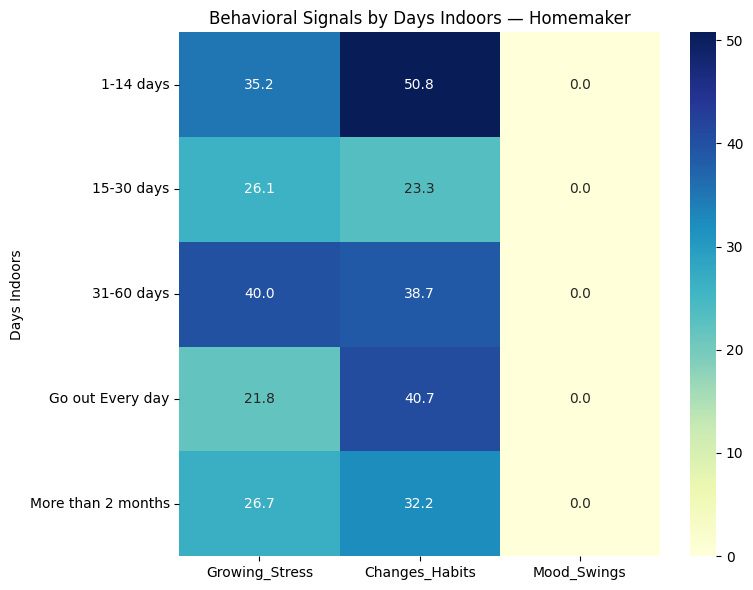

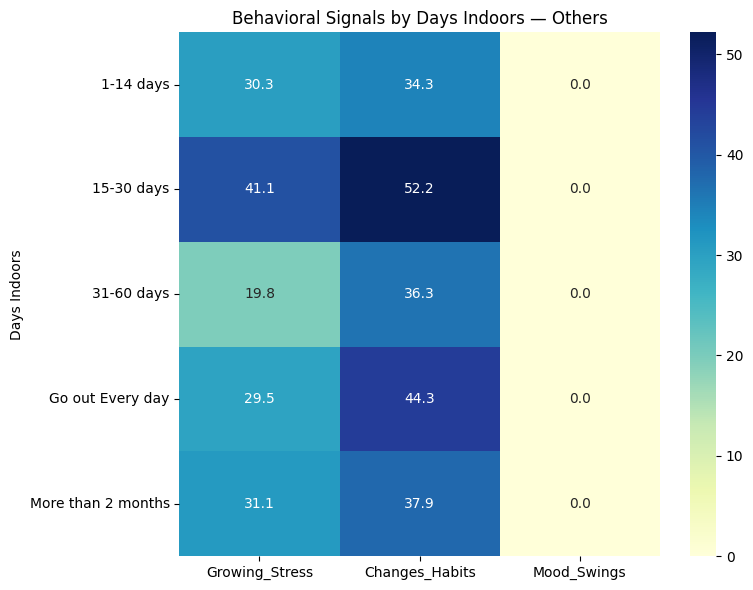

In [35]:
# Function to plot grouped bar chart for each signal
def plot_behavior_by_occupation(signal):
    for occ in df['Occupation'].unique():
        subset = df[df['Occupation'] == occ]
        dist = subset.groupby(['Days_Indoors', signal]).size().unstack(fill_value=0)
        dist.columns = dist.columns.str.strip().str.capitalize()  # Normalize column names
        share = dist.div(dist.sum(axis=1), axis=0) * 100

        # Use .get() to safely access "Yes" column
        yes_share = share.get('Yes', pd.Series([0]*len(share), index=share.index))

        plt.figure(figsize=(8,6))
        yes_share.plot(kind='bar', color='mediumseagreen')
        plt.title(f'{signal} = Yes by Days Indoors — {occ}')
        plt.ylabel('Percentage')
        plt.xlabel('Days Indoors')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"{signal}_Yes_by_DaysIndoors_{occ}.png")


# Generate plots
for signal in ['Growing_Stress', 'Changes_Habits']:
    plot_behavior_by_occupation(signal)

# Optional: Heatmap per occupation
for occ in df['Occupation'].unique():
    subset = df[df['Occupation'] == occ]
    heat_data = {}
    for signal in ['Growing_Stress', 'Changes_Habits', 'Mood_Swings']:
        dist = subset.groupby(['Days_Indoors', signal]).size().unstack(fill_value=0)
        share = dist.div(dist.sum(axis=1), axis=0) * 100
        heat_data[signal] = share.get('Yes', pd.Series([0]*len(share), index=share.index))
    heat_df = pd.DataFrame(heat_data)

    plt.figure(figsize=(8,6))
    sns.heatmap(heat_df, annot=True, cmap='YlGnBu', fmt='.1f')
    plt.title(f'Behavioral Signals by Days Indoors — {occ}')
    plt.ylabel('Days Indoors')
    plt.tight_layout()
    plt.savefig(f"Heatmap_Behavior_by_DaysIndoors_{occ}.png")


In [36]:
# Save to Excel
with pd.ExcelWriter("Occupation_DaysIndoors_BehavioralSignals.xlsx") as writer:
    for occ in df['Occupation'].unique():
        subset = df[df['Occupation'] == occ]
        for signal in ['Growing_Stress', 'Changes_Habits']:
            dist = subset.groupby(['Days_Indoors', signal]).size().unstack(fill_value=0)
            share = dist.div(dist.sum(axis=1), axis=0) * 100
            share.to_excel(writer, sheet_name=f"{occ}_{signal}")

__Insight__: *How Indoor Time Shapes Stress, Habits, and Mood — Occupation-Specific Behavioral Signals
This analysis explores how the number of days spent indoors influences three key behavioral outcomes across occupational groups*:
- Growing Stress
- Changes in Habits
- Mood Swings

__*Key Findings by Occupation*__:
__*Corporate Professionals*__:
- Stress peaks at 15–30 days indoors (50.6%) and remains high at 31–60 days (42.4%)

- Habit change increases steadily with indoor time, peaking at >2 months (34.8%)

- Mood swings are consistently absent — possibly due to structured routines or underreporting

__*Students*__
- Stress spikes at 31–60 days (44.6%) and >2 months (42.5%)

- Habit change is highest at 1–14 days (52.1%) — suggesting rapid lifestyle disruption

- Mood swings again show no recorded “Yes” responses — indicating either resilience or data gaps

*__Business Professionals__*
- Stress highest at 1–14 days (44.3%) and >2 months (41.5%)

- Habit change peaks when going out every day (55.0%) — possibly due to erratic routines

- Mood swings remain unreported

__*Homemakers*__
- Stress highest at 31–60 days (40.0%) and 1–14 days (35.2%)

- Habit change peaks at 1–14 days (50.8%) — reflecting early disruption

- Mood swings consistently absent

__*Others*__
- Stress peaks at 15–30 days (41.1%) and >2 months (31.1%)

- Habit change highest at 15–30 days (52.2%) and “Go out every day” (44.3%)

__*Mood swings not recorded*__
*Notable Absence: Mood Swings*
Across all occupations and indoor durations, no “Yes” responses were recorded for Mood Swings. This could reflect:
- Survey design limitations
- Underreporting due to stigma
- Misclassification or missing data

*This absence is analytically significant — it suggests that while stress and habit changes are acknowledged, emotional volatility may be less visible or less validated in self-reporting.*

__*Strategic Takeaway*__

*Indoor confinement affects people differently depending on their occupational identity. Corporate professionals and students show clear stress escalation with prolonged isolation. Homemakers and business professionals experience rapid habit disruption even with short indoor durations. The absence of mood swing data points to a blind spot in emotional self-awareness or survey sensitivity.For mental health strategists, this insight calls for role-specific interventions that address both behavioral and emotional dimensions. For leaders, it’s a reminder that structured routines don’t always protect against stress. For innovators, it’s a prompt to design tools that surface hidden emotional signals. And from a strategic lens, it reinforces that mental health isn’t just about what people report — it’s about what they may not yet recognize.*

__*Do high Days-Indoors and Social-Weakness jointly align with higher stress?*__

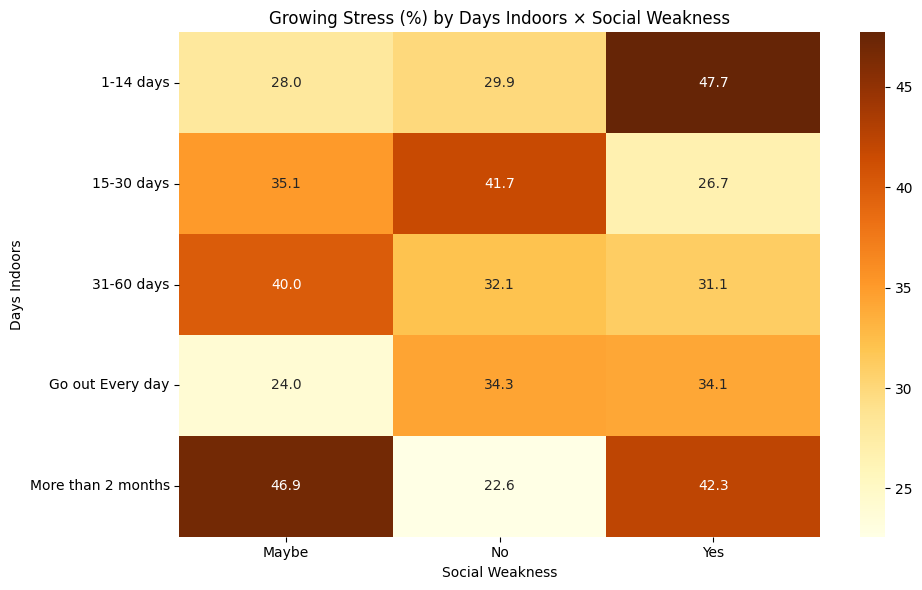

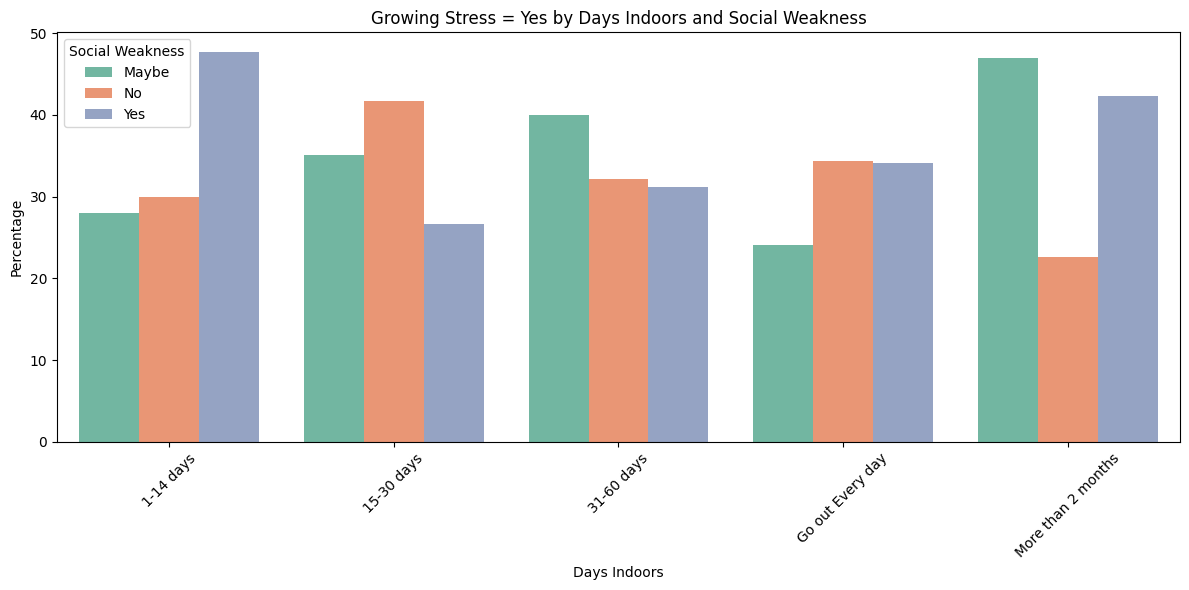

In [37]:

# Heatmap: % Stress = Yes by Days_Indoors × Social_Weakness
heat_data = df[df['Growing_Stress'] == 'Yes']
heatmap_df = heat_data.groupby(['Days_Indoors', 'Social_Weakness']).size().unstack(fill_value=0)

# Normalize by total respondents in each bin
total_counts = df.groupby(['Days_Indoors', 'Social_Weakness']).size().unstack(fill_value=0)
stress_share = (heatmap_df / total_counts * 100).fillna(0).round(1)

plt.figure(figsize=(10,6))
sns.heatmap(stress_share, annot=True, cmap='YlOrBr', fmt='.1f')
plt.title('Growing Stress (%) by Days Indoors × Social Weakness')
plt.ylabel('Days Indoors')
plt.xlabel('Social Weakness')
plt.tight_layout()
plt.savefig("Heatmap_Stress_DaysIndoors_SocialWeakness.png")

# Grouped Bar Chart
grouped = df.groupby(['Days_Indoors', 'Social_Weakness', 'Growing_Stress']).size().unstack(fill_value=0)
grouped = grouped.div(grouped.sum(axis=1), axis=0) * 100
grouped_yes = grouped.get('Yes', pd.Series([0]*len(grouped), index=grouped.index)).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=grouped_yes, x='Days_Indoors', y='Yes', hue='Social_Weakness', palette='Set2')
plt.title('Growing Stress = Yes by Days Indoors and Social Weakness')
plt.ylabel('Percentage')
plt.xlabel('Days Indoors')
plt.xticks(rotation=45)
plt.legend(title='Social Weakness')
plt.tight_layout()
plt.savefig("GroupedBar_Stress_DaysIndoors_SocialWeakness.png")

In [38]:
# Save to Excel
stress_share.to_excel("Stress_by_DaysIndoors_SocialWeakness.xlsx")

*This analysis explores how Days Indoors and Social Weakness jointly influence the likelihood of experiencing Growing Stress. It reveals how behavioral isolation and emotional fragility interact to shape mental health outcomes.*

__*Key Findings*__:
__High-Risk Zones__
- The highest stress level (47.7%) occurs among individuals with high Social Weakness who stayed indoors for 1–14 days.

- Surprisingly, stress drops for the same group at 15–30 days (26.7%) — suggesting a possible adaptation phase or reporting inconsistency.

- For those with low Social Weakness, stress peaks at 15–30 days (41.7%) — indicating that even socially resilient individuals are vulnerable to prolonged isolation.

__Interaction Effects__
- Short indoor durations (1–14 days) combined with high Social Weakness show the strongest stress response — possibly due to abrupt lifestyle disruption without coping mechanisms.

- Extended indoor time (>2 months) also correlates with elevated stress across all social weakness levels, especially for “Maybe” (46.9%) and “Yes” (42.3%).

- The heatmap reveals that stress is not linearly tied to indoor time — it’s shaped by the interaction between isolation and emotional support capacity.

__*Strategic Takeaway*__
*Stress is not just a function of time indoors — it’s a compound outcome shaped by both behavioral isolation and emotional vulnerability. Individuals with high social weakness are especially sensitive to abrupt changes, while even socially strong individuals show stress escalation with prolonged confinement.For mental health strategists, this insight calls for dual-axis interventions: reducing isolation and strengthening social resilience. For leaders, it’s a reminder that workplace wellness must address both structure and support. For innovators, it’s a prompt to build tools that detect compound risk signals. And from a strategic lens, it reinforces that mental health isn’t binary — it’s a dynamic interplay of context, capacity, and connection.*

*__Are mood-swing levels different for self-employed vs others?__*

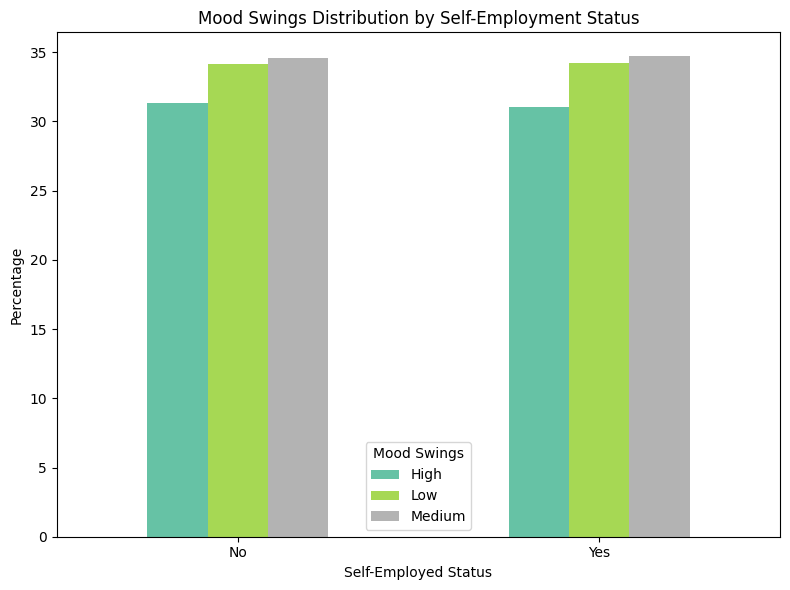

In [41]:

# Calculate % distribution of Mood Swings per Self_Employed status
pivot = df.groupby(['self_employed', 'Mood_Swings']).size().unstack(fill_value=0)
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent = pivot_percent.round(2)

# Plot: Grouped Bar Chart
pivot_percent.plot(kind='bar', figsize=(8,6), colormap='Set2')
plt.title('Mood Swings Distribution by Self-Employment Status')
plt.ylabel('Percentage')
plt.xlabel('Self-Employed Status')
plt.xticks(rotation=0)
plt.legend(title='Mood Swings')
plt.tight_layout()
plt.savefig("MoodSwings_by_SelfEmployed_GroupedBar.png")



In [42]:
# Save to Excel
pivot_percent.to_excel("MoodSwings_by_SelfEmployed.xlsx")

*This analysis explores whether self-employed individuals experience different levels of mood swings compared to those who are not self-employed. The goal is to uncover whether occupational autonomy correlates with emotional volatility.*

__*Key Findings*__:

__*Distribution Overview*__:

- Mood swing levels are remarkably similar across both groups:

- High: ~31% for both self-employed and non-self-employed

- Medium: ~34.6–34.7%

- Low: ~34.1–34.2%

*The differences are statistically negligible, suggesting that self-employment status alone does not significantly influence mood swing levels.*

__*Interpretation*__
Despite assumptions that self-employment might increase emotional strain due to financial uncertainty or isolation, the data shows no clear emotional disadvantage.Conversely, it also doesn’t show emotional protection — meaning autonomy doesn’t necessarily buffer against mood volatility either.

__*Strategic Takeaway*__

*Self-employment does not appear to be a strong predictor of mood swings. Emotional volatility is likely shaped more by contextual factors (e.g., support systems, workload, personality traits) than by employment status alone. For mental health strategists, this insight suggests that interventions should focus on individual stressors and coping mechanisms, rather than occupational labels.From a leadership lens, it’s a reminder that emotional well-being must be addressed across all work models. For innovators, it’s a prompt to design mental health tools that adapt to diverse work identities. And from a strategic perspective, it reinforces that autonomy is not a guarantee of emotional stability — it’s just one piece of a much larger puzzle.*

__*Do people with non-self-employed status and prior mental health history suffer more?*__

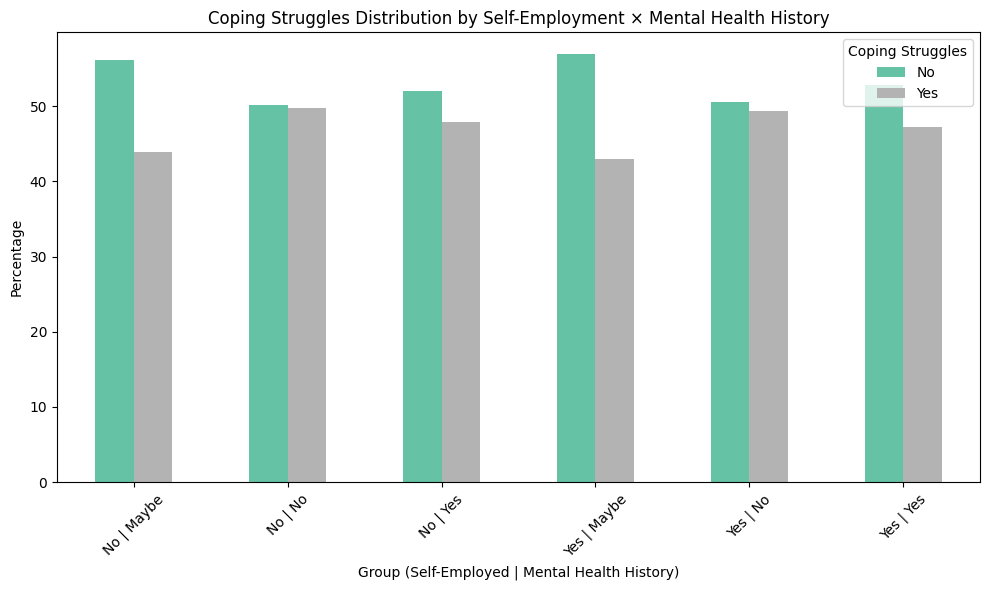

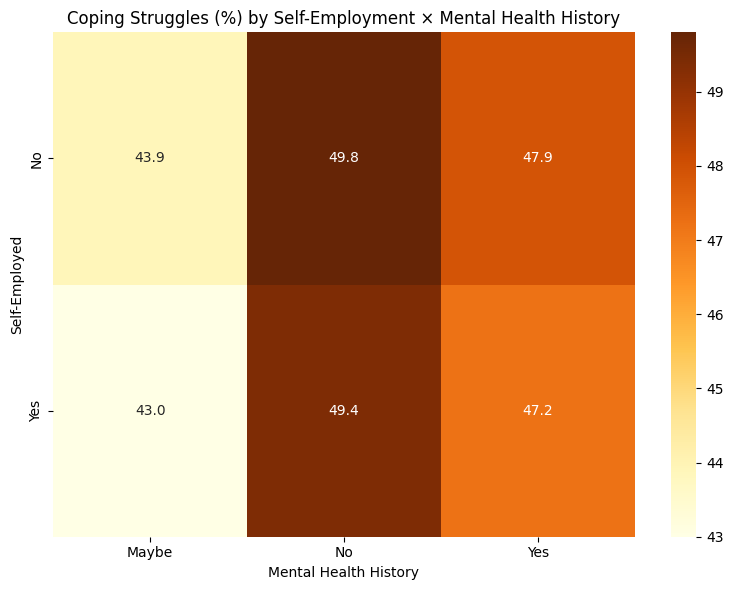

In [46]:
# Create combined category
df['Group'] = df['self_employed'] + ' | ' + df['Mental_Health_History']

# Calculate % distribution of Coping_Struggles per group
pivot = df.groupby(['Group', 'Coping_Struggles']).size().unstack(fill_value=0)
pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent = pivot_percent.round(2)

# Plot: Grouped Bar Chart
pivot_percent.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title('Coping Struggles Distribution by Self-Employment × Mental Health History')
plt.ylabel('Percentage')
plt.xlabel('Group (Self-Employed | Mental Health History)')
plt.xticks(rotation=45)
plt.legend(title='Coping Struggles')
plt.tight_layout()
plt.savefig("CopingStruggles_by_SelfEmployed_MentalHealth_GroupedBar.png")

# Optional: Heatmap of % Coping_Struggles = Yes
heat_data = df[df['Coping_Struggles'] == 'Yes']
heatmap_df = heat_data.groupby(['self_employed', 'Mental_Health_History']).size().unstack(fill_value=0)

# Normalize by total respondents in each bin
total_counts = df.groupby(['self_employed', 'Mental_Health_History']).size().unstack(fill_value=0)
stress_share = (heatmap_df / total_counts * 100).fillna(0).round(1)

plt.figure(figsize=(8,6))
sns.heatmap(stress_share, annot=True, cmap='YlOrBr', fmt='.1f')
plt.title('Coping Struggles (%) by Self-Employment × Mental Health History')
plt.ylabel('Self-Employed')
plt.xlabel('Mental Health History')
plt.tight_layout()
plt.savefig("Heatmap_CopingStruggles_SelfEmployed_MentalHealth.png")

In [47]:
pivot_percent.to_excel("CopingStruggles_by_SelfEmployed_MentalHealth.xlsx")

*This analysis explores whether individuals who are not self-employed and have a history of mental health challenges are more likely to report coping struggles — a key question in understanding how occupational structure interacts with emotional resilience.*

__*Key Findings*__
__*Coping Struggles by Group*__
__Among non-self-employed individuals:__

- Those with mental health history report 47.9% coping struggles.

- Those without history: 49.8%

- Those with uncertain history (“Maybe”): 43.9%

- Among self-employed individuals:

- Those with mental health history report 47.2% coping struggles.

- Those without history: 49.4%

- Those with uncertain history: 43.0%

__*Interpretation*__
- The difference between self-employed and non-self-employed individuals is minimal across all mental health history categories.

- Surprisingly, non-self-employed individuals without mental health history show the highest coping struggle rate (49.8%) — suggesting that employment structure alone does not buffer emotional strain.

- Mental health history does correlate with elevated coping struggles, but not disproportionately more for non-self-employed individuals.

__*Strategic Takeaway*__

*The data challenges the assumption that structured employment amplifies emotional vulnerability in those with mental health history. Instead, it suggests that coping struggles are widespread, regardless of employment type — and that mental health history is a consistent but not exclusive predictor.For mental health strategists, this insight calls for universal support systems, not just targeted interventions. For leaders, it’s a reminder that emotional strain can exist even in seemingly stable roles. For innovators, it’s a prompt to build tools that detect and respond to hidden emotional burdens, beyond surface-level labels. And from a strategic lens, it reinforces that resilience is not just about history — it’s about the systems we build around people.*

__*Which Occupation × Days-Indoors groups report the most loss of work interest? Do Days-Indoors associate with more Growing-Stress and Habit-Change, and do those co-occur with Coping-Struggles?*__

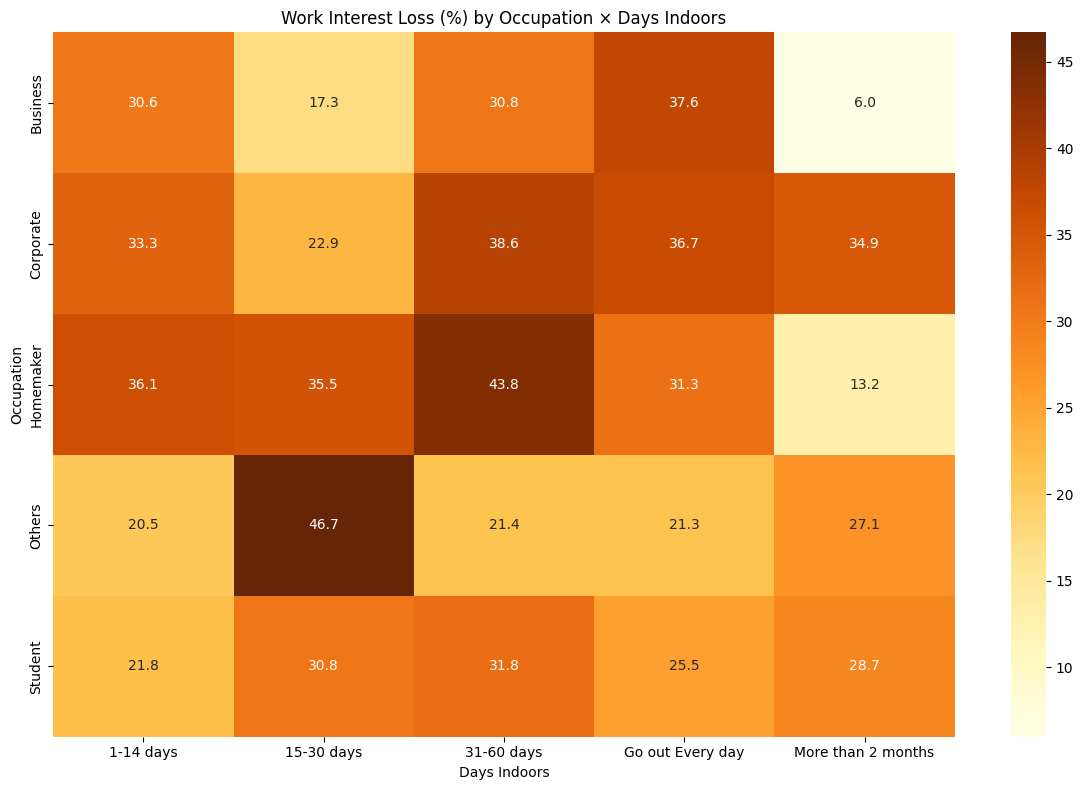

In [48]:
### Part A: Work Interest Loss Heatmap
loss_df = df[df['Work_Interest'] == 'Yes']
loss_counts = loss_df.groupby(['Occupation', 'Days_Indoors']).size().unstack(fill_value=0)
total_counts = df.groupby(['Occupation', 'Days_Indoors']).size().unstack(fill_value=0)
loss_percent = (loss_counts / total_counts * 100).fillna(0).round(1)

plt.figure(figsize=(12,8))
sns.heatmap(loss_percent, annot=True, cmap='YlOrBr', fmt='.1f')
plt.title('Work Interest Loss (%) by Occupation × Days Indoors')
plt.ylabel('Occupation')
plt.xlabel('Days Indoors')
plt.tight_layout()
plt.savefig("Heatmap_WorkInterestLoss_Occupation_DaysIndoors.png")



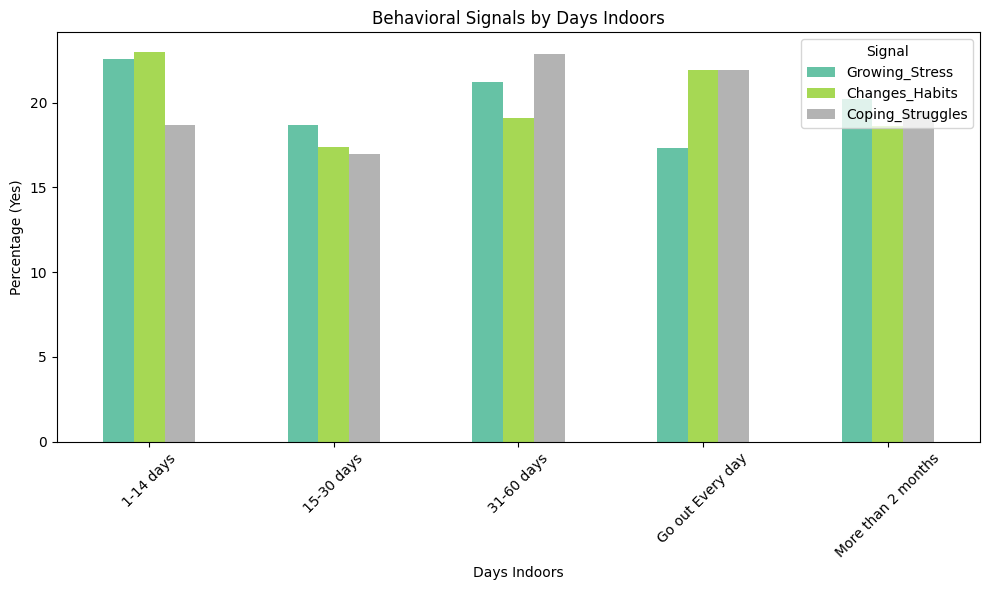

In [49]:
### Part B: Stress Mechanism Grouped Bar Chart
signals = ['Growing_Stress', 'Changes_Habits', 'Coping_Struggles']
signal_data = {}

for signal in signals:
    signal_df = df[df[signal] == 'Yes']
    signal_counts = signal_df['Days_Indoors'].value_counts(normalize=True) * 100
    signal_data[signal] = signal_counts.round(1)

signal_df = pd.DataFrame(signal_data).fillna(0)

signal_df.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title('Behavioral Signals by Days Indoors')
plt.ylabel('Percentage (Yes)')
plt.xlabel('Days Indoors')
plt.xticks(rotation=45)
plt.legend(title='Signal')
plt.tight_layout()
plt.savefig("GroupedBar_StressMechanism_DaysIndoors.png")


In [50]:

# Save to Excel
with pd.ExcelWriter("WorkInterestLoss_and_StressMechanism.xlsx") as writer:
    loss_percent.to_excel(writer, sheet_name="WorkInterestLoss")
    signal_df.to_excel(writer, sheet_name="StressMechanism")


*This analysis identifies which Occupation × Days-Indoors groups report the highest levels of Work_Interest = Yes, interpreted as loss of interest in work.*

__*High-Risk Groups*__
- Corporate professionals show the highest disengagement at 31–60 days indoors (38.6%)

- Others report peak loss at 15–30 days (46.7%) — possibly due to fragmented or informal work structures

- Students and Homemakers show elevated loss at 31–60 days and >2 months, suggesting that prolonged isolation erodes motivation even in non-traditional work roles

__*Interpretation*__
- Loss of work interest is not linear — it spikes at specific indoor durations depending on occupation

- Structured roles (Corporate, Business) show delayed disengagement, while flexible roles (Others, Students) react earlier

*This layer explores how Days Indoors correlates with:*

- Growing Stress

- Changes in Habits

- Coping Struggles


__*Key Findings*__
__*Behavioral Escalation*__
- Growing Stress peaks at 1–14 days (22.6%) and 31–60 days (21.2%) — suggesting both early disruption and mid-term fatigue

- Habit Change is highest at 1–14 days (23%) and Go out every day (21.9%) — indicating that both confinement and erratic routines destabilize behavior

- Coping Struggles peak at 31–60 days (22.9%) and Go out every day (21.9%) — showing that stress and habit disruption co-occur with emotional breakdown

__*Mechanism*__
- Isolation triggers stress, which leads to habit disruption, and eventually coping failure

- The 31–60 day window emerges as a critical tipping point across all signals

__*Strategic Takeaway*__

*Work disengagement is not just a motivational issue — it’s a behavioral outcome of prolonged isolation and emotional strain. The data reveals a clear mechanism: Days Indoors → Stress → Habit Change → Coping Struggles → Work Interest Loss. For mental health strategists, this insight calls for early intervention before the 30–60 day threshold. For leaders, it’s a reminder that productivity loss is rooted in emotional and behavioral erosion. For innovators, it’s a prompt to build tools that detect and interrupt this cascade. And from a strategic lens, it reinforces that occupational engagement is not just about tasks — it’s about the emotional scaffolding that supports them.*

#### END 